# Préparation des jeux de données SST pour ML

**Pipeline :** Données brutes → Enrichissement → Filtre (4) → Nettoyage (5) → Transformation (6) → Split train/val/test (7) → Statistiques (8) → Analyse par cluster (9)

**Sources :**
- CSV : `0_Data/0_Raw/ExportSST/export_SSTCAD_20260227/`
- GIS (clusters, U_Puissance) : `0_Data/1_Structured/DATA_GIS_Filtered.parquet`


## 1. Configuration

In [1]:
# Constantes et chemins
import gc
import re
from pathlib import Path
import json
from urllib.request import urlopen
from urllib.error import URLError

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chemins (depuis 2_Program)
PATH_RAW = Path("0_Data/0_Raw/ExportSST/export_SSTCAD_20260227")
PATH_STRUCTURED = Path("0_Data/1_Structured")
PATH_TRAINING = Path("0_Data/3_training")
PATH_VALIDATION = Path("0_Data/4_Validation")
PATH_TEST = Path("0_Data/5_Test")
PATH_GIS = Path("0_Data/1_Structured/DATA_GIS_Filtered.parquet")
PATH_SST_RAW = PATH_STRUCTURED / "sst_raw.parquet"
PATH_SST_ENRICHED = PATH_STRUCTURED / "sst_enriched.parquet"

PATH_SST_FILTERED = PATH_STRUCTURED / "sst_filtered.parquet"
PATH_SST_FILTERED_CLEAN = PATH_STRUCTURED / "sst_filtered_clean.parquet"
PATH_SST_FILTERED_TRANSFO = PATH_STRUCTURED / "sst_filtered_transfo.parquet"

# Paramètres
MIN_YEARS_DATA = 1.1
MIN_VALID_RATIO = 0.95
# Agrégation : False = pas 15 min (pas de moyenne quart d’heure, pas FREQ 1 min au sol).
# True = section 4 : cadres 15 min locaux (Zurich) —
#   fin de cadre à :15 (:00–:14), :30 (:15–:29), :45 (:30–:44), :00 heure suivante (:45–:59) ;
#   moyenne de PuisCpt (et TempRet sur les mêmes fenêtres pour alignement).
AGGREGATION_15MIN = True
# True si la section 2 a pré-agrégé PuisCpt au pas 15 min (défaut : aligné avec AGGREGATION_15MIN).
# Mettre False si vous réutilisez un vieux sst_raw minute sans régénérer la section 2.
PUISCPT_PREAGGREGATED_IN_RAW = AGGREGATION_15MIN
FREQ = "15min" if AGGREGATION_15MIN else "1min"  # Grille météo / enrichissement (section 3)
# Répartition temporelle globale, sections 7–8 : ordre **Entraînement → Validation → Test**
# (coupures issues du bloc d’optimisation en début de section 7 sur la série TempExt).
# Parts minimales de la plage [dmin_globale, dmax_globale] (durée calendaire) :
SPLIT_FRAC_TRAIN_MIN = 0.5
SPLIT_FRAC_VAL_MIN = 0.2
SPLIT_FRAC_TEST_MIN = 0.1
# Froid : pondération Wasserstein supplémentaire sur TempExt < seuil (°C)
TEMPEXT_COLD_THRESHOLD_C = 15.0
SPLIT_OPTIM_COLD_W1_WEIGHT = 2.0
SPLIT_OPTIM_QUANTILE_WEIGHT = 0.5
# Grille d'exploration : None → pas ≈ max(1, n_timestamps // 200)
SPLIT_OPTIM_GRID_STRIDE = None
# Ancien découpage depuis dmax — conservé pour référence ; la section 7 ne l’utilise plus.
SPLIT_TEST_LAST_MONTHS = 2
SPLIT_VAL_WINDOW_START_OFFSET_MONTHS = 6
SPLIT_VAL_WINDOW_END_OFFSET_MONTHS = 3
TRAIN_MIN_MONTHS = 6

# Météo - Bulle (Suisse)
BULLE_LAT = 46.6175
BULLE_LON = 7.0581

# Créer les dossiers de sortie
for p in [PATH_STRUCTURED, PATH_TRAINING, PATH_VALIDATION, PATH_TEST]:
    p.mkdir(parents=True, exist_ok=True)

## 2. Import des données brutes

Chargement de tous les CSV sans filtre, fusion ni échantillonnage.
Format des colonnes : `EGID.DATATYPE.valeur` et `EGID.DATATYPE.inv` (format long : date, EGID, DATA_TYPE, valeur, inv).

Si **`AGGREGATION_15MIN`** (section 1) : **PuisCpt** est agrégé au **pas 15 min** (cadres Zurich, règle 10/15) via `sst_bucket_aggregate.py` — réduction forte de `sst_raw` / `sst_enriched` et de la RAM en section 4 ; **TempRet** reste en résolution brute jusqu'à la section 4.


In [2]:
def parse_date(s):
    return pd.to_datetime(s, format="%d/%m/%Y %H:%M", errors="coerce")

def load_raw_csvs(path_raw: Path) -> pd.DataFrame:
    """Charge tous les CSV en un seul DataFrame (format long)."""
    records = []
    csv_files = sorted(path_raw.glob("*.csv"))
    
    for fp in csv_files:
        try:
            df = pd.read_csv(fp, sep=";", encoding="utf-8", on_bad_lines="warn")
        except UnicodeDecodeError:
            df = pd.read_csv(fp, sep=";", encoding="cp1252", on_bad_lines="warn")
        except (pd.errors.EmptyDataError, pd.errors.ParserError):
            print(f"Ignoré (vide/invalide): {fp.name}")
            continue
        
        if df.shape[1] < 3:
            continue
        
        # Colonnes : date, EGID_DATATYPE, inv
        date_col, val_col, inv_col = df.columns[0], df.columns[1], df.columns[2]
        # Extraire EGID et DATA_TYPE du header (ex: 1510837_TempRet)
        parts = val_col.split("_", 1)
        if len(parts) != 2:
            continue
        egid, data_type = parts[0], parts[1]
        
        df = df.copy()
        df["date"] = parse_date(df[date_col])
        df = df.dropna(subset=["date"])
        df["EGID"] = egid
        df["DATA_TYPE"] = data_type
        df["valeur"] = pd.to_numeric(df[val_col], errors="coerce")
        df["inv"] = pd.to_numeric(df[inv_col], errors="coerce").fillna(0)
        records.append(df[["date", "EGID", "DATA_TYPE", "valeur", "inv"]])
    
    if not records:
        return pd.DataFrame()
    return pd.concat(records, ignore_index=True)

df_raw = load_raw_csvs(PATH_RAW)
if AGGREGATION_15MIN:
    from sst_bucket_aggregate import aggregate_puiscpt_to_15min_raw

    _m_pc = df_raw["DATA_TYPE"].eq("PuisCpt")
    if _m_pc.any():
        _n_pc_before = int(_m_pc.sum())
        df_pc = aggregate_puiscpt_to_15min_raw(df_raw.loc[_m_pc].copy())
        df_raw = pd.concat([df_raw.loc[~_m_pc], df_pc], ignore_index=True)
        del df_pc
        gc.collect()
        _n_pc_after = int(df_raw["DATA_TYPE"].eq("PuisCpt").sum())
        print(
            f"PuisCpt agrégé 15 min à l'import : {_n_pc_before:,} → {_n_pc_after:,} lignes"
        )
print(f"Lignes brutes : {len(df_raw):,}")
print(f"EGIDs uniques : {df_raw['EGID'].nunique()}")
print(f"DATA_TYPE : {df_raw['DATA_TYPE'].unique().tolist()}")
df_raw.head(10)

Ignoré (vide/invalide): techant17950_20260227.csv
PuisCpt agrégé 15 min à l'import : 209,012,011 → 13,934,468 lignes
Lignes brutes : 45,387,991
EGIDs uniques : 369
DATA_TYPE : ['TempRet', 'PuisCpt']


,date,EGID,DATA_TYPE,valeur,inv
0,2026-02-27 13:15:00,235004706,TempRet,28.395556,0.0
1,2026-02-27 13:00:00,235004706,TempRet,28.413333,0.0
2,2026-02-27 12:45:00,235004706,TempRet,28.622222,0.0
3,2026-02-27 12:30:00,235004706,TempRet,29.170000,0.0
4,2026-02-27 12:15:00,235004706,TempRet,29.283333,0.0
5,2026-02-27 12:00:00,235004706,TempRet,29.310000,0.0
6,2026-02-27 11:45:00,235004706,TempRet,29.328889,0.0
7,2026-02-27 11:30:00,235004706,TempRet,29.367778,0.0
8,2026-02-27 11:15:00,235004706,TempRet,29.387778,0.0
9,2026-02-27 11:00:00,235004706,TempRet,29.465556,0.0


In [3]:
# Export parquet brut
df_raw.to_parquet(PATH_SST_RAW, index=False)
print(f"Exporté : {PATH_SST_RAW}")
del df_raw
import gc; gc.collect()

Exporté : 0_Data\1_Structured\sst_raw.parquet


0

## 3. Enrichissement des données

- Plage temporelle complète au pas configurable (15 min ou 1 min selon `AGGREGATION_15MIN`)
- Données météo (température extérieure) pour toute la plage
- La **section 4** recalcule `date_15min` (quarts d’heure locaux + overlap) et réassocie `TempExt` par `merge_asof` sur la grille enrichie
- Réexport parquet

In [4]:
if not PATH_SST_RAW.exists():
    raise FileNotFoundError(
        f"Fichier requis absent : {PATH_SST_RAW}. Exécuter la section 2 (Import brut) d'abord."
    )
df_raw = pd.read_parquet(PATH_SST_RAW)

def fetch_temp_ext(start_dt, end_dt):
    """Récupère la température extérieure (Bulle) via Open-Meteo."""
    url = (
        "https://archive-api.open-meteo.com/v1/archive?"
        f"latitude={BULLE_LAT}&longitude={BULLE_LON}"
        f"&start_date={start_dt.strftime('%Y-%m-%d')}&end_date={end_dt.strftime('%Y-%m-%d')}"
        "&hourly=temperature_2m&timezone=UTC"
    )
    try:
        with urlopen(url, timeout=60) as r:
            d = json.loads(r.read().decode())
    except Exception as e:
        print(f"Erreur API météo : {e}")
        return pd.Series(dtype=float)
    h = d.get("hourly", {})
    times = h.get("time", [])
    temps = h.get("temperature_2m", [])
    if not times:
        return pd.Series(dtype=float)
    df = pd.DataFrame({"time": times, "temp": temps})
    df["time"] = pd.to_datetime(df["time"], utc=True)
    df = df.set_index("time")
    rng = pd.date_range(start=start_dt, end=end_dt, freq=FREQ, tz="UTC")
    return df["temp"].reindex(rng, method="ffill").fillna(0.0)

# Plage temporelle globale (FREQ = 15min ou 1min selon AGGREGATION_15MIN)
ts_min = df_raw["date"].min().floor(FREQ)
ts_max = df_raw["date"].max().ceil(FREQ)
full_index = pd.date_range(start=ts_min, end=ts_max, freq=FREQ)

# Données météo (conversion dates en UTC)
def to_utc(ts):
    return pd.Timestamp(ts).tz_localize("Europe/Zurich", ambiguous=True, nonexistent="shift_forward").tz_convert("UTC")
ts_min_utc = to_utc(ts_min)
ts_max_utc = to_utc(ts_max)
temp_ext = fetch_temp_ext(ts_min_utc, ts_max_utc)
full_index_utc = pd.date_range(start=ts_min_utc, end=ts_max_utc, freq=FREQ, tz="UTC")

# DataFrame Dates (UTC) + TempExt
df_dates = pd.DataFrame({"Dates": full_index_utc, "TempExt": temp_ext.values})

# Fusion : convertir dates brutes en UTC, aligner sur FREQ
df_work = df_raw.copy()
df_work["date_15min"] = (
    df_work["date"]
    .dt.tz_localize("Europe/Zurich", ambiguous=True, nonexistent="shift_forward")
    .dt.tz_convert("UTC")
    .dt.floor(FREQ)
)
df_dates_merge = df_dates.rename(columns={"Dates": "date_15min"})
df_enriched = df_work.merge(df_dates_merge, on="date_15min", how="left")
df_enriched["TempExt"] = df_enriched["TempExt"].fillna(0.0)

df_enriched.to_parquet(PATH_SST_ENRICHED, index=False)
print(f"Enrichi : {len(df_enriched):,} lignes, TempExt ajoutée")
head_preview = df_enriched.head()
del df_raw, df_work, df_dates, df_dates_merge, temp_ext, df_enriched
gc.collect()
head_preview

Enrichi : 45,387,991 lignes, TempExt ajoutée


,date,EGID,DATA_TYPE,valeur,inv,date_15min,TempExt
0,2026-02-27 13:15:00,235004706,TempRet,28.395556,0.0,2026-02-27 12:15:00+00:00,15.4
1,2026-02-27 13:00:00,235004706,TempRet,28.413333,0.0,2026-02-27 12:00:00+00:00,15.4
2,2026-02-27 12:45:00,235004706,TempRet,28.622222,0.0,2026-02-27 11:45:00+00:00,15.5
3,2026-02-27 12:30:00,235004706,TempRet,29.170000,0.0,2026-02-27 11:30:00+00:00,15.5
4,2026-02-27 12:15:00,235004706,TempRet,29.283333,0.0,2026-02-27 11:15:00+00:00,15.5


## 4. Filtre et répartition

1. **GIS** : ne garder que les EGID présents dans `DATA_GIS_Filtered` (clusters).

2. **Données brutes (avant agrégation 15 min)** : pour chaque EGID, **TempRet** et **PuisCpt** doivent chacun avoir une étendue `date` **> MIN_YEARS_DATA** (1,1 an en section 1) **sur l’historique importé**. Proportion **> 95 %** de lignes avec **`inv = 0`** par type.

3. **Pas de temps 15 min (si `AGGREGATION_15MIN`)** : cadres en **Europe/Zurich** (fin de cadre **HH:15** = minutes 0–14, **HH:30** = 15–29, **HH:45** = 30–44, **(HH+1):00** = 45–59). Dans chaque fenêtre de *n* points : soit *v* le nombre de points **valides** (`inv = 0` et valeur finie). Si *v* × 15 ≥ 10 × *n* (équivalent à « au moins 10 valides sur 15 » en proportion), **moyenne sur les seuls points valides** et **`inv = 0`** ; sinon **moyenne sur tous les points** et **`inv = 1`**. **PuisCpt** est déjà agrégé ainsi en **section 2** (`sst_bucket_aggregate.py`) ; en section 4, le **groupby** lourd ne s’applique plus qu’à **TempRet** (PuisCpt : recalcul vectoriel de `date_15min` seulement).

4. **Chevauchement des deux types** : troncature avant `max(1re date TempRet avec valeur renseignée, idem PuisCpt)` ; ne garder que les `date_15min` où **les deux** types ont une **valeur non NaN**.

5. **Série alignée** : étendue sur `date_15min` (après intersection) **≥ `MIN_YEARS_DATA`** (section 1).

6. Export **`sst_filtered.parquet`** (long : `TempExt`, `date_15min`, `cluster`, `date` locale Zurich sans fuseau).

Découpage train / validation / test en **section 7**.


In [2]:
# =============================================================================
# 4. FILTRE — Jeu enrichi → sst_filtered.parquet
# =============================================================================
# Entrées : PATH_SST_ENRICHED (section 3), PATH_GIS (clusters + EGID autorisés)
# Sortie  : PATH_SST_FILTERED (long : date, date_15min UTC naïf, TempExt, cluster, …)
# =============================================================================

# Pas de temps / fuseau : module `sst_bucket_aggregate` (identique section 2 pour PuisCpt).
from sst_bucket_aggregate import aggregate_long, norm_utc_naive_series


if not PATH_SST_ENRICHED.exists():
    raise FileNotFoundError(
        f"Fichier requis absent : {PATH_SST_ENRICHED}. Exécuter la section 3 (Enrichissement) d'abord."
    )

# -----------------------------------------------------------------------------
# 4.1  Chargement du Parquet enrichi — colonnes strictement nécessaires (RAM)
# -----------------------------------------------------------------------------
_cols_main = ["date", "EGID", "DATA_TYPE", "valeur", "inv"]
try:
    df_enriched = pd.read_parquet(
        PATH_SST_ENRICHED, columns=_cols_main, engine="pyarrow"
    )
except Exception:
    df_enriched = pd.read_parquet(PATH_SST_ENRICHED)
    df_enriched = df_enriched[_cols_main]

# -----------------------------------------------------------------------------
# 4.2  Filtre GIS — ne conserver que les EGID présents dans DATA_GIS_Filtered
# -----------------------------------------------------------------------------
df_gis = pd.read_parquet(PATH_GIS)
df_gis["U_NO_EGID"] = df_gis["U_NO_EGID"].astype(str)
egid_to_cluster = df_gis.set_index("U_NO_EGID")["cluster"].to_dict()
del df_gis
gc.collect()

valid_egids = set(egid_to_cluster.keys())
_mask = df_enriched["EGID"].astype(str).isin(valid_egids)
df_f = df_enriched.loc[_mask].copy()
del df_enriched, _mask, _cols_main
gc.collect()

# -----------------------------------------------------------------------------
# 4.3  Table météo — (date_15min, TempExt) dédupliquée, triée pour merge_asof
# -----------------------------------------------------------------------------
try:
    ext_tbl = pd.read_parquet(
        PATH_SST_ENRICHED,
        columns=["date_15min", "TempExt"],
        engine="pyarrow",
    )
except Exception:
    ext_tbl = pd.read_parquet(PATH_SST_ENRICHED)[["date_15min", "TempExt"]]
ext_tbl = ext_tbl.drop_duplicates(subset=["date_15min"]).sort_values(
    "date_15min", kind="mergesort"
)
gc.collect()

# -----------------------------------------------------------------------------
# 4.4  Typage des colonnes mesures (inv / valeur)
# -----------------------------------------------------------------------------
df_f["inv"] = pd.to_numeric(df_f["inv"], errors="coerce").fillna(1).astype(np.int8)
df_f["valeur"] = pd.to_numeric(df_f["valeur"], errors="coerce")


# =============================================================================
# 4.B  Chevauchement TempRet / PuisCpt (même grille date_15min)
# =============================================================================

def joint_trim_and_inner_dates(df: pd.DataFrame) -> pd.DataFrame:
    """Par EGID :

    1. Tronquer avant max(1re date TempRet avec donnée, 1re date PuisCpt avec donnée)
       — « donnée » = valeur non NaN (peu importe inv).
    2. Ne garder que les instants où **les deux** types ont `valeur` non NaN.
    """
    df = df.copy()
    df["date_15min"] = norm_utc_naive_series(df["date_15min"])

    def _ns_keys(series: pd.Series) -> set:
        u = norm_utc_naive_series(series)
        return set(u.values.astype("datetime64[ns]").astype(np.int64))

    chunks = []
    egid_s = df["EGID"].astype(str)
    for egid in egid_s.unique():
        g = df.loc[egid_s == egid]
        g_tr = g[g["DATA_TYPE"] == "TempRet"]
        g_pc = g[g["DATA_TYPE"] == "PuisCpt"]
        if g_tr.empty or g_pc.empty:
            continue
        has_data_tr = g_tr["valeur"].notna()
        has_data_pc = g_pc["valeur"].notna()
        if not has_data_tr.any() or not has_data_pc.any():
            continue
        t0 = max(
            g_tr.loc[has_data_tr, "date_15min"].min(),
            g_pc.loc[has_data_pc, "date_15min"].min(),
        )
        g = g.loc[g["date_15min"] >= t0]
        mtr = (g["DATA_TYPE"] == "TempRet") & g["valeur"].notna()
        mpc = (g["DATA_TYPE"] == "PuisCpt") & g["valeur"].notna()
        d_tr = _ns_keys(g.loc[mtr, "date_15min"])
        d_pc = _ns_keys(g.loc[mpc, "date_15min"])
        keep_ns = d_tr & d_pc
        if not keep_ns:
            continue
        g_key = norm_utc_naive_series(g["date_15min"]).values.astype("datetime64[ns]").astype(np.int64)
        g = g.iloc[np.isin(g_key, np.array(list(keep_ns), dtype=np.int64))].copy()
        chunks.append(g)
    if not chunks:
        return pd.DataFrame(columns=df.columns)
    return pd.concat(chunks, ignore_index=True, copy=False)


# =============================================================================
# 4.C  Filtres EGID
# =============================================================================

def _span_years(s: pd.Series) -> float:
    delta = pd.Timestamp(s.max()) - pd.Timestamp(s.min())
    return float(delta.total_seconds()) / (365.25 * 86400.0)


def filter_egids_pre_aggregate(df: pd.DataFrame) -> list:
    """Données brutes (avant agrégation), pour chaque EGID :

    - TempRet : > MIN_VALID_RATIO de lignes avec inv==0 **et** étendue `date` > MIN_YEARS_DATA
    - PuisCpt : idem
    """
    if df.empty:
        return []
    eg = df["EGID"].astype(str)
    inv_ok = df["inv"].to_numpy() == 0
    m_tr_np = df["DATA_TYPE"].to_numpy() == "TempRet"
    m_pc_np = df["DATA_TYPE"].to_numpy() == "PuisCpt"
    keep = []
    for e in eg.unique():
        m = (eg == e).to_numpy()
        if not (m & m_tr_np).any() or not (m & m_pc_np).any():
            continue
        ok = True
        for mask_dt in (m_tr_np, m_pc_np):
            mm = m & mask_dt
            if not mm.any():
                ok = False
                break
            if _span_years(df.loc[mm, "date"]) < MIN_YEARS_DATA:
                ok = False
                break
            vr = float(inv_ok[mm].mean())
            if vr < MIN_VALID_RATIO:
                ok = False
                break
        if ok:
            keep.append(e)
    return keep


def filter_egids_post_overlap(df: pd.DataFrame) -> list:
    """Série alignée : étendue (intersection) >= MIN_YEARS_DATA ; les deux types présents."""
    if df.empty:
        return []
    keep = []
    for e, sub in df.groupby(df["EGID"].astype(str), sort=False):
        if (sub["DATA_TYPE"] == "TempRet").sum() == 0 or (sub["DATA_TYPE"] == "PuisCpt").sum() == 0:
            continue
        if _span_years(sub["date_15min"]) >= MIN_YEARS_DATA:
            keep.append(e)
    return keep


def summarize_pre_filter_failures(df: pd.DataFrame) -> None:
    """Affiche pourquoi le filtre pré-agrégation exclut tout (durée / inv par type)."""
    if df.empty:
        print("Diagnostic filtre brut : DataFrame vide après GIS.")
        return
    eg = df["EGID"].astype(str)
    inv_ok = df["inv"].to_numpy() == 0
    m_tr = df["DATA_TYPE"].to_numpy() == "TempRet"
    m_pc = df["DATA_TYPE"].to_numpy() == "PuisCpt"
    n_both = 0
    fail_tr_span = fail_pc_span = 0
    fail_tr_r = fail_pc_r = 0
    spans_tr = []
    spans_pc = []
    for e in eg.unique():
        m = (eg == e).to_numpy()
        if not (m & m_tr).any() or not (m & m_pc).any():
            continue
        n_both += 1
        mm_tr = m & m_tr
        mm_pc = m & m_pc
        st = _span_years(df.loc[mm_tr, "date"])
        sp = _span_years(df.loc[mm_pc, "date"])
        spans_tr.append(st)
        spans_pc.append(sp)
        if st < MIN_YEARS_DATA:
            fail_tr_span += 1
        if sp < MIN_YEARS_DATA:
            fail_pc_span += 1
        if float(inv_ok[mm_tr].mean()) < MIN_VALID_RATIO:
            fail_tr_r += 1
        if float(inv_ok[mm_pc].mean()) < MIN_VALID_RATIO:
            fail_pc_r += 1
    print("--- Diagnostic filtre brut (EGID avec TempRet + PuisCpt) ---")
    print(f"Nombre d'EGID concernés : {n_both}")
    if spans_tr:
        print(
            f"TempRet  span (ans) : min={min(spans_tr):.3f}, "
            f"médiane={float(np.median(spans_tr)):.3f}, max={max(spans_tr):.3f}"
        )
    if spans_pc:
        print(
            f"PuisCpt  span (ans) : min={min(spans_pc):.3f}, "
            f"médiane={float(np.median(spans_pc)):.3f}, max={max(spans_pc):.3f}"
        )
    print(
        f"Échecs étendue < {MIN_YEARS_DATA} an (par type) : "
        f"TempRet={fail_tr_span}, PuisCpt={fail_pc_span}"
    )
    print(
        f"Échecs part inv=0 < {MIN_VALID_RATIO:.0%} : "
        f"TempRet={fail_tr_r}, PuisCpt={fail_pc_r}"
    )


# =============================================================================
# 4.5  Filtre qualité **brute**
# =============================================================================
keep_pre = filter_egids_pre_aggregate(df_f)
print(
    f"GIS + critères bruts (>{MIN_YEARS_DATA} an par type, >{MIN_VALID_RATIO:.0%} inv=0 par type) : {len(keep_pre)} EGID"
)
if not keep_pre:
    summarize_pre_filter_failures(df_f)
    raise ValueError(
        "Section 4 : aucun EGID sur les données brutes. Si le diagnostic montre surtout des « étendue < … » "
        "sur PuisCpt ou TempRet, la fenêtre SST importée est trop courte pour ce type (voir MIN_YEARS_DATA en section 1) : "
        "élargir l’export ou abaisser MIN_YEARS_DATA en section 1."
    )
df_f = df_f[df_f["EGID"].astype(str).isin(keep_pre)]
print(f"  → {len(df_f):,} lignes après filtre EGID")

# -----------------------------------------------------------------------------
# 4.6  Agrégation pas de temps + normalisation des timestamps
# -----------------------------------------------------------------------------
df_f = aggregate_long(
    df_f,
    aggregation_15min=AGGREGATION_15MIN,
    freq=FREQ,
    puiscpt_preaggregated=PUISCPT_PREAGGREGATED_IN_RAW,
)
df_f["date_15min"] = norm_utc_naive_series(df_f["date_15min"])

# -----------------------------------------------------------------------------
# 4.7  Jointure météo
# -----------------------------------------------------------------------------
ext_tbl = ext_tbl.copy()
ext_tbl["date_15min"] = norm_utc_naive_series(ext_tbl["date_15min"])
ext_tbl = ext_tbl.sort_values("date_15min", kind="mergesort")
df_f = df_f.sort_values("date_15min", kind="mergesort")
df_f = pd.merge_asof(
    df_f,
    ext_tbl,
    on="date_15min",
    direction="backward",
)
df_f["TempExt"] = pd.to_numeric(df_f["TempExt"], errors="coerce").fillna(0.0).astype(np.float32)
print(f"Lignes après agrégation : {len(df_f):,}")
del ext_tbl
gc.collect()

# -----------------------------------------------------------------------------
# 4.8  Chevauchement deux types (plages avec les deux séries)
# -----------------------------------------------------------------------------
df_f = joint_trim_and_inner_dates(df_f)
print(
    f"Lignes après chevauchement TempRet+PuisCpt : {len(df_f):,} ; EGID restants : {df_f['EGID'].nunique() if not df_f.empty else 0}"
)

# -----------------------------------------------------------------------------
# 4.9  Étendue >= MIN_YEARS_DATA sur la timeline alignée
# -----------------------------------------------------------------------------
keep_egids = filter_egids_post_overlap(df_f)
df_f = df_f[df_f["EGID"].astype(str).isin(keep_egids)]
print(
    f"EGIDs après filtre étendue alignée (>={MIN_YEARS_DATA} an) : {len(keep_egids)}"
)
if not keep_egids:
    raise ValueError(
        f"Section 4 : aucun EGID avec assez de chevauchement deux types (>={MIN_YEARS_DATA} an sur grille 15 min)."
    )

# -----------------------------------------------------------------------------
# 4.10  Export
# -----------------------------------------------------------------------------
df_f["date"] = (
    pd.to_datetime(df_f["date_15min"], utc=True)
    .dt.tz_convert("Europe/Zurich")
    .dt.tz_localize(None)
)
df_f["cluster"] = df_f["EGID"].astype(str).map(egid_to_cluster)
df_f.to_parquet(PATH_SST_FILTERED, index=False)
print(f"Exporté : {PATH_SST_FILTERED} ({len(df_f):,} lignes)")
del df_f
gc.collect()


GIS + critères bruts (>1.1 an par type, >95% inv=0 par type) : 252 EGID
  → 35,395,595 lignes après filtre EGID
Lignes après agrégation : 35,395,595


C:\Users\luandrey\AppData\Local\Temp\ipykernel_32876\1430523643.py:114: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  return pd.concat(chunks, ignore_index=True, copy=False)


Lignes après chevauchement TempRet+PuisCpt : 20,881,924 ; EGID restants : 252
EGIDs après filtre étendue alignée (>=1.1 an) : 252
Exporté : 0_Data\1_Structured\sst_filtered.parquet (20,881,924 lignes)


0

## 5. Nettoyage

À partir de **`sst_filtered.parquet`** (section 4) : séries déjà **alignées** (grille 15 min si activée, overlap TempRet + PuisCpt). Format long :
- **PuisCpt** : `inv` ≠ 0 → `valeur` remplacée par 0
- **TempRet** : `inv` ≠ 0 → `valeur` remplacée par la médiane des valeurs valides (`inv` = 0) pour le même EGID

Export : **`sst_filtered_clean.parquet`**


In [3]:
if not PATH_SST_FILTERED.exists():
    raise FileNotFoundError(
        f"Fichier requis absent : {PATH_SST_FILTERED}. Exécuter la section 4 d'abord."
    )
df = pd.read_parquet(PATH_SST_FILTERED)

m_puis = (df["DATA_TYPE"] == "PuisCpt") & (df["inv"] != 0)
df.loc[m_puis, "valeur"] = 0.0

m_tr = df["DATA_TYPE"] == "TempRet"
medians = df.loc[m_tr & (df["inv"] == 0)].groupby("EGID")["valeur"].median()
for egid, med in medians.items():
    m_bad = m_tr & (df["EGID"] == egid) & (df["inv"] != 0)
    fill = float(med) if pd.notna(med) else 0.0
    df.loc[m_bad, "valeur"] = fill

df.to_parquet(PATH_SST_FILTERED_CLEAN, index=False)
print(f"Exporté : {PATH_SST_FILTERED_CLEAN} ({len(df):,} lignes)")
del df
gc.collect()
print("Nettoyage terminé.")


Exporté : 0_Data\1_Structured\sst_filtered_clean.parquet (20,881,924 lignes)
Nettoyage terminé.


## 6. Transformation

À partir de **`sst_filtered_clean.parquet`** (format long). La colonne **`date`** est l’instant Zurich (sans fuseau) aligné sur **`date_15min`** (section 4) :
1. **Encodage cyclique** : jour (1-366), jour de la semaine (0-6), heure (0-23) → cos/sin (6 colonnes)
2. **TempExt_norm** : normalisation 0-1 (−20 °C → 0, +40 °C → 1, bornes)
3. **PuisCpt** : colonne **`valeur_fc`** = `valeur` / `U_Puissance_kW` (clip [0, 1])
4. **TempRet** : colonne **`valeur_norm`** = normalisation (20 °C → 0, 80 °C → 1, bornes)

Export : **`sst_filtered_transfo.parquet`**. La section 7 pivote ensuite vers le format large par cluster et split.


In [4]:
def cycl_encode(val, max_val):
    angle = 2 * np.pi * val / max_val
    return np.cos(angle), np.sin(angle)


def parse_puissance(x):
    if pd.isna(x):
        return np.nan
    s = str(x).upper().replace(" ", "")
    m = re.search(r"([0-9.]+)\s*K?W?", s)
    return float(m.group(1)) if m else np.nan


if not PATH_SST_FILTERED_CLEAN.exists():
    raise FileNotFoundError(
        f"Fichier requis absent : {PATH_SST_FILTERED_CLEAN}. Exécuter la section 5 d'abord."
    )

df_gis = pd.read_parquet(PATH_GIS)
df_gis["U_NO_EGID"] = df_gis["U_NO_EGID"].astype(str)
if "U_PUISSANCE_kW" in df_gis.columns:
    egid_to_puissance = df_gis.set_index("U_NO_EGID")["U_PUISSANCE_kW"].to_dict()
else:
    egid_to_puissance = (
        df_gis.set_index("U_NO_EGID")["U_PUISSANCE"].apply(parse_puissance).to_dict()
    )
del df_gis
gc.collect()

df = pd.read_parquet(PATH_SST_FILTERED_CLEAN)
dates = pd.to_datetime(df["date"])
df["dayofyear_cos"], df["dayofyear_sin"] = cycl_encode(dates.dt.dayofyear - 1, 366)
df["dayofweek_cos"], df["dayofweek_sin"] = cycl_encode(dates.dt.dayofweek, 7)
df["hour_cos"], df["hour_sin"] = cycl_encode(dates.dt.hour, 24)
df["TempExt_norm"] = np.clip((df["TempExt"] + 20) / 60, 0, 1)

puis_mask = df["DATA_TYPE"] == "PuisCpt"
temp_mask = df["DATA_TYPE"] == "TempRet"
pui = pd.to_numeric(df["EGID"].astype(str).map(egid_to_puissance), errors="coerce")
df["valeur_fc"] = np.nan
ok_puis = puis_mask & pui.notna() & (pui > 0)
df.loc[ok_puis, "valeur_fc"] = np.clip(
    df.loc[ok_puis, "valeur"].astype(float) / pui[ok_puis].astype(float), 0, 1
)
df["valeur_norm"] = np.nan
df.loc[temp_mask, "valeur_norm"] = np.clip(
    (df.loc[temp_mask, "valeur"].astype(float) - 20) / 60, 0, 1
)

df.to_parquet(PATH_SST_FILTERED_TRANSFO, index=False)
print(f"Exporté : {PATH_SST_FILTERED_TRANSFO} ({len(df):,} lignes)")
del df
gc.collect()
print("Transformation terminée.")


Exporté : 0_Data\1_Structured\sst_filtered_transfo.parquet (20,881,924 lignes)
Transformation terminée.


## 7. Split

À partir de **`sst_filtered_transfo.parquet`** (section 6) et de la grille `TempExt` du fichier enrichi :

1. **Optimisation des coupures** (bloc code ci-dessous) : grille temporelle globale `date_15min` + `TempExt` ; instants `SPLIT_CHRONO_VAL_START_UTC` et `SPLIT_CHRONO_TEST_START_UTC` minimisant un score **Wasserstein** + écarts de **quantiles**, avec poids accru pour `TempExt` < `TEMPEXT_COLD_THRESHOLD_C`, sous contraintes `SPLIT_FRAC_*` (section 1).
2. Répartition par **cluster** — mêmes coupures pour tous les EGID : entraînement puis validation puis test, **sans trou** sur la ligne de temps.
3. Export **`cluster{N}.parquet`** dans `0_Data/3_training`, `0_Data/4_Validation`, `0_Data/5_Test` (format large : `Dates`, mesures, `.inv`, encodages cycliques, `TempExt_norm`, `*_fc`, `*_norm`).


In [2]:
# Optimisation des coupures train / val / test (ordre chronologique, grille TempExt globale)
from chrono_split_optimize import compute_chrono_split_bounds, print_chrono_split_report

if not PATH_SST_ENRICHED.exists():
    raise FileNotFoundError(
        f"Fichier requis absent : {PATH_SST_ENRICHED}. Exécuter les sections 1–6 d'abord."
    )
if not PATH_SST_FILTERED_TRANSFO.exists():
    raise FileNotFoundError(
        f"Fichier requis absent : {PATH_SST_FILTERED_TRANSFO}. Exécuter la section 6 d'abord."
    )

_clip_bounds = pd.read_parquet(PATH_SST_FILTERED_TRANSFO, columns=["date_15min"])
_clip_lo = pd.to_datetime(_clip_bounds["date_15min"], utc=True).min()
_clip_hi = pd.to_datetime(_clip_bounds["date_15min"], utc=True).max()
del _clip_bounds
gc.collect()

_chrono_res = compute_chrono_split_bounds(
    PATH_SST_ENRICHED,
    frac_train_min=SPLIT_FRAC_TRAIN_MIN,
    frac_val_min=SPLIT_FRAC_VAL_MIN,
    frac_test_min=SPLIT_FRAC_TEST_MIN,
    tempext_cold_threshold_c=TEMPEXT_COLD_THRESHOLD_C,
    cold_w1_weight=SPLIT_OPTIM_COLD_W1_WEIGHT,
    quantile_weight=SPLIT_OPTIM_QUANTILE_WEIGHT,
    grid_stride=SPLIT_OPTIM_GRID_STRIDE,
    clip_timeline_start_utc=_clip_lo,
    clip_timeline_end_utc=_clip_hi,
)
SPLIT_CHRONO_VAL_START_UTC = _chrono_res.val_start_utc
SPLIT_CHRONO_TEST_START_UTC = _chrono_res.test_start_utc
print_chrono_split_report(_chrono_res)


Optimisation split chronologique (score W1 + froid + quantiles) :
  dmin_g_utc=2024-12-21 23:45:00+00:00, dmax_g_utc=2026-02-27 13:30:00+00:00, T=432 days 13:45:00
  score=11.04030, indices grille (_val, _test)=(21592, 37346)
  SPLIT_CHRONO_VAL_START_UTC = 2025-08-03 21:45:00+00:00
  SPLIT_CHRONO_TEST_START_UTC = 2026-01-15 01:15:00+00:00
  Parts calendaires : train=0.520, val=0.379, test=0.101
  Train TempExt : n=21592, froid<15°C: 75.1%
  Val   TempExt : n=15754, froid<15°C: 80.1%
  Test  TempExt : n=4178, froid<15°C: 99.0%


In [3]:
def split_train_val_test(df_egid: pd.DataFrame):
    """
    Répartition chronologique globale (section 7, optimisation) :
    - entraînement : [dmin, SPLIT_CHRONO_VAL_START_UTC)
    - validation : [SPLIT_CHRONO_VAL_START_UTC, SPLIT_CHRONO_TEST_START_UTC)
    - test : [SPLIT_CHRONO_TEST_START_UTC, dmax]
    """
    dmin = df_egid["date"].min()
    dmax = df_egid["date"].max()
    min_total_days = int(round(MIN_YEARS_DATA * 365.25))
    span_days = (dmax - dmin).days
    if span_days < min_total_days:
        return None, None, None

    d = pd.to_datetime(df_egid["date"], utc=True)
    v0 = pd.Timestamp(SPLIT_CHRONO_VAL_START_UTC).tz_convert("UTC")
    t0 = pd.Timestamp(SPLIT_CHRONO_TEST_START_UTC).tz_convert("UTC")
    dmin_utc = pd.Timestamp(dmin)
    if dmin_utc.tzinfo is None:
        dmin_utc = dmin_utc.tz_localize("UTC")
    else:
        dmin_utc = dmin_utc.tz_convert("UTC")
    dmax_utc = pd.Timestamp(dmax)
    if dmax_utc.tzinfo is None:
        dmax_utc = dmax_utc.tz_localize("UTC")
    else:
        dmax_utc = dmax_utc.tz_convert("UTC")

    train_min_days = int(round(TRAIN_MIN_MONTHS * 30.4375))
    m_train = (d >= dmin_utc) & (d < v0)
    m_val = (d >= v0) & (d < t0)
    m_test = (d >= t0) & (d <= dmax_utc)
    if not m_train.any():
        return None, None, None
    d_tr_min, d_tr_max = d[m_train].min(), d[m_train].max()
    tr_span = (d_tr_max - d_tr_min).days
    if tr_span < train_min_days:
        return None, None, None
    return (
        df_egid[m_train],
        df_egid[m_val],
        df_egid[m_test],
    )


def build_split_df(df_part, df_dates_full):
    """Format large : mesures brutes (valeur, inv) + features déjà calculées en section 6."""
    if df_part.empty:
        return None
    df_part = df_part.copy()
    # Aligner avec dates_range tz=UTC (sst_filtered_transfo a souvent date_15min naïf = instant UTC)
    df_part["date_15min"] = pd.to_datetime(df_part["date_15min"], utc=True)
    dates_range = pd.date_range(
        df_part["date_15min"].min(),
        df_part["date_15min"].max(),
        freq=FREQ,
        tz="UTC",
    )
    out = pd.DataFrame({"Dates": dates_range})
    dmin, dmax = dates_range.min(), dates_range.max()
    dtf = pd.to_datetime(df_dates_full["date_15min"], utc=True)
    mask = (dtf >= dmin) & (dtf <= dmax)
    temp_map = (
        df_dates_full.loc[mask]
        .assign(date_15min=lambda x: pd.to_datetime(x["date_15min"], utc=True))
        .set_index("date_15min")["TempExt"]
    )
    out["TempExt"] = out["Dates"].map(lambda t: float(temp_map.get(t, 0.0)))

    df_part["col"] = df_part["EGID"].astype(str) + "." + df_part["DATA_TYPE"]
    pv = df_part.pivot_table(index="date_15min", columns="col", values="valeur", aggfunc="mean")
    pv_inv = df_part.pivot_table(index="date_15min", columns="col", values="inv", aggfunc="max")

    feat_cols = [
        "dayofyear_cos",
        "dayofyear_sin",
        "dayofweek_cos",
        "dayofweek_sin",
        "hour_cos",
        "hour_sin",
        "TempExt_norm",
    ]
    tfeat = df_part.drop_duplicates(subset=["date_15min"]).set_index("date_15min")
    tfeat = tfeat[[c for c in feat_cols if c in tfeat.columns]]

    pv_fc = df_part.pivot_table(index="date_15min", columns="col", values="valeur_fc", aggfunc="mean")
    pv_fc.columns = [f"{c}_fc" for c in pv_fc.columns]
    pv_nt = df_part.pivot_table(index="date_15min", columns="col", values="valeur_norm", aggfunc="mean")
    pv_nt.columns = [f"{c}_norm" for c in pv_nt.columns]

    out = out.set_index("Dates")
    out = out.join(pv.reindex(dates_range), how="left")
    out = out.join(pv_inv.add_suffix(".inv").reindex(dates_range), how="left")
    out = out.join(tfeat.reindex(dates_range), how="left")
    out = out.join(pv_fc.reindex(dates_range), how="left")
    out = out.join(pv_nt.reindex(dates_range), how="left")
    return out.reset_index()


if not PATH_SST_FILTERED_TRANSFO.exists():
    raise FileNotFoundError(
        f"Fichier requis absent : {PATH_SST_FILTERED_TRANSFO}. Exécuter la section 6 d'abord."
    )
if not PATH_SST_ENRICHED.exists():
    raise FileNotFoundError(
        f"Fichier requis absent : {PATH_SST_ENRICHED}. Exécuter la section 3 d'abord."
    )

df_f = pd.read_parquet(PATH_SST_FILTERED_TRANSFO)
df_enriched = pd.read_parquet(PATH_SST_ENRICHED)
df_dates_full = df_enriched[["date_15min", "TempExt"]].drop_duplicates(subset=["date_15min"])
del df_enriched
gc.collect()

_parquet_count = 0
for cluster_id in df_f["cluster"].dropna().unique():
    sub_cluster = df_f[df_f["cluster"] == cluster_id]
    if sub_cluster.empty:
        continue
    egid_splits = {}
    for egid in sub_cluster["EGID"].unique():
        egid_all = sub_cluster[sub_cluster["EGID"] == egid]
        tr, va, te = split_train_val_test(egid_all)
        if tr is not None:
            egid_splits[egid] = {"train": tr, "val": va, "test": te}
    if not egid_splits:
        continue
    split_parts = {"train": [], "val": [], "test": []}
    for _egid, data in egid_splits.items():
        for key in split_parts:
            part = data[key]
            if not part.empty:
                split_parts[key].append(part)
    if not split_parts["train"]:
        continue
    for split_name, path in [("train", PATH_TRAINING), ("val", PATH_VALIDATION), ("test", PATH_TEST)]:
        parts = split_parts.get(split_name, [])
        if not parts:
            continue
        combined = pd.concat(parts, ignore_index=True)
        out_df = build_split_df(combined, df_dates_full)
        if out_df is not None and not out_df.empty:
            fname = f"cluster{int(cluster_id)}.parquet"
            out_df.to_parquet(path / fname, index=False)
            print(f"  {path.name}/{fname}")
            _parquet_count += 1

print(f"Export Split terminé. ({_parquet_count} fichiers .parquet)")
del df_f, df_dates_full
gc.collect()


  3_training/cluster4.parquet
  4_Validation/cluster4.parquet
  5_Test/cluster4.parquet
  3_training/cluster6.parquet
  4_Validation/cluster6.parquet
  5_Test/cluster6.parquet
  3_training/cluster3.parquet
  4_Validation/cluster3.parquet
  5_Test/cluster3.parquet
  3_training/cluster5.parquet
  4_Validation/cluster5.parquet
  5_Test/cluster5.parquet
Export Split terminé. (12 fichiers .parquet)


0

## 8. Statistiques

Analyse de la composition des jeux de données par cluster et DATA_TYPE pour vérifier la représentativité (RandomForest, XGBoost, LSTM). Les libellés « archivées ≥ MIN_YEARS_DATA » et les plages train / validation / test suivent le **découpage chronologique global** de la **section 7** (`SPLIT_CHRONO_VAL_START_UTC`, `SPLIT_CHRONO_TEST_START_UTC`).


Optimisation split chronologique (score W1 + froid + quantiles) :
  dmin_g_utc=2024-12-21 23:45:00+00:00, dmax_g_utc=2026-02-27 13:30:00+00:00, T=432 days 13:45:00
  score=11.04030, indices grille (_val, _test)=(21592, 37346)
  SPLIT_CHRONO_VAL_START_UTC = 2025-08-03 21:45:00+00:00
  SPLIT_CHRONO_TEST_START_UTC = 2026-01-15 01:15:00+00:00
  Parts calendaires : train=0.520, val=0.379, test=0.101
  Train TempExt : n=21592, froid<15°C: 75.1%
  Val   TempExt : n=15754, froid<15°C: 80.1%
  Test  TempExt : n=4178, froid<15°C: 99.0%


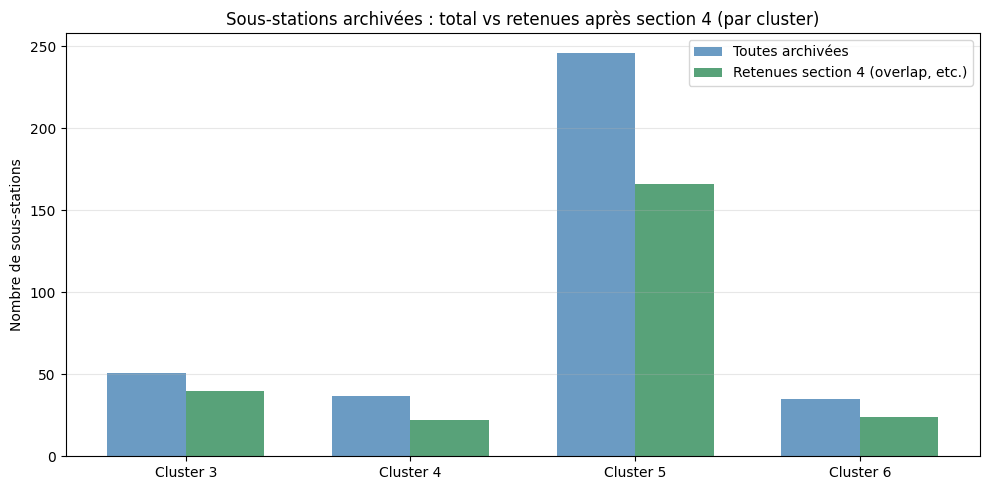

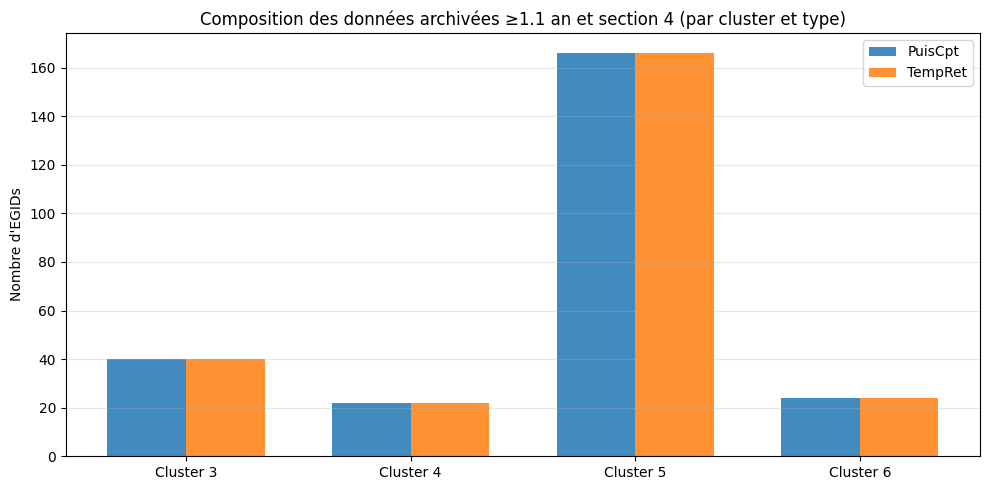

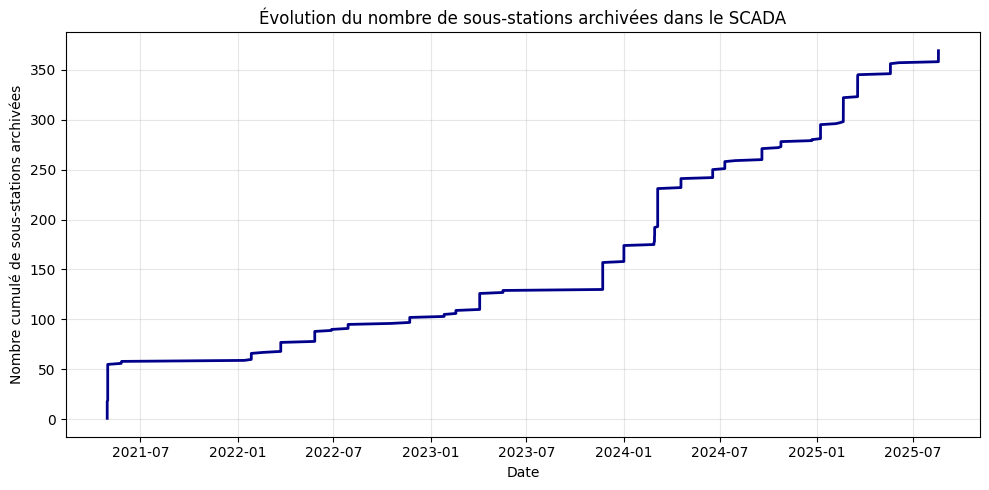

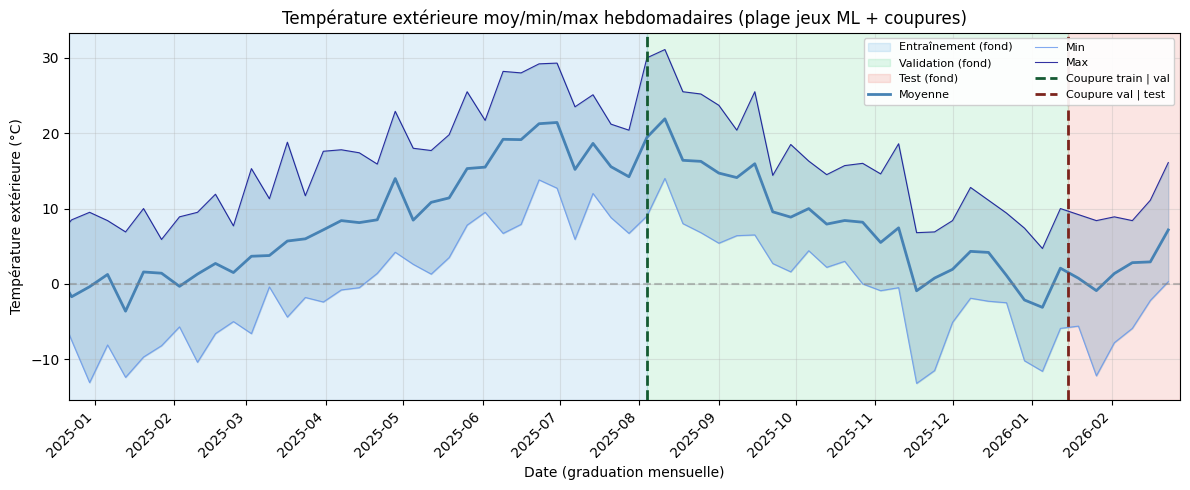

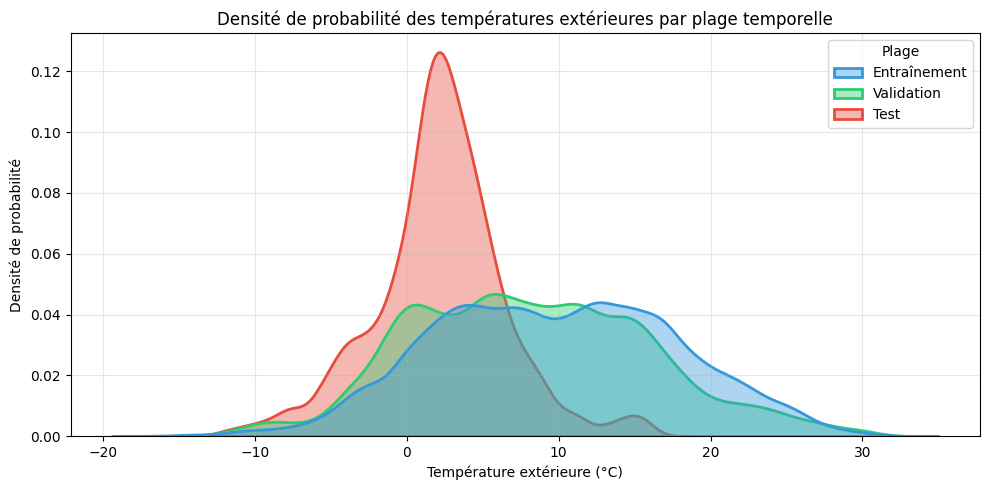

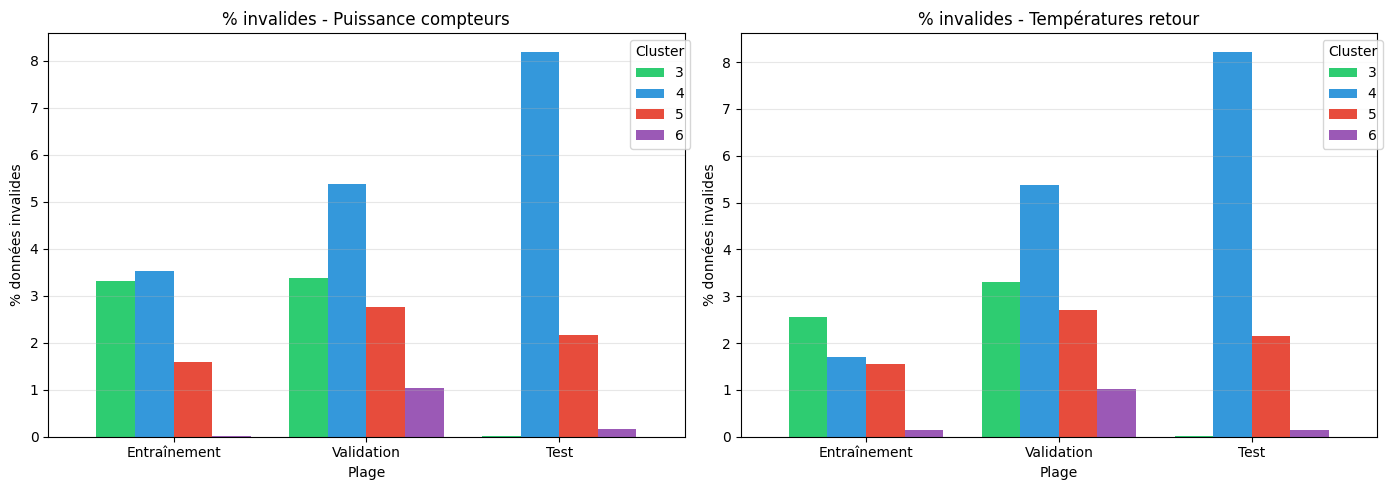

5078

In [2]:
# Section exécutable après config (1) + pipeline complet une fois (parquets générés)
if not PATH_SST_ENRICHED.exists():
    raise FileNotFoundError(
        f"Fichier requis absent : {PATH_SST_ENRICHED}. Exécuter les sections 2 à 7 au moins une fois pour les exports par cluster."
    )
df_enriched = pd.read_parquet(PATH_SST_ENRICHED)
df_gis = pd.read_parquet(PATH_GIS)
df_gis["U_NO_EGID"] = df_gis["U_NO_EGID"].astype(str)
egid_to_cluster = df_gis.set_index("U_NO_EGID")["cluster"].to_dict()
valid_egids = set(egid_to_cluster.keys())

if PATH_SST_FILTERED.exists():
    keep_egids = (
        pd.read_parquet(PATH_SST_FILTERED, columns=["EGID"])["EGID"]
        .astype(str)
        .unique()
        .tolist()
    )
else:
    def filter_egids(df):
        df = df.copy()
        df["EGID_str"] = df["EGID"].astype(str)
        grp = df.groupby("EGID_str")
        span = grp["date"].agg(lambda x: (x.max() - x.min()).days / 365.25)
        valid_ratio = grp["inv"].apply(lambda x: (x == 0).mean())
        ok = (span >= MIN_YEARS_DATA) & (valid_ratio >= MIN_VALID_RATIO)
        return ok[ok].index.tolist()

    df_f = df_enriched[df_enriched["EGID"].astype(str).isin(valid_egids)].copy()
    keep_egids = filter_egids(df_f)
    del df_f
    gc.collect()

# Données pour les graphiques
df_archived = df_enriched[df_enriched["EGID"].astype(str).isin(valid_egids)].copy()
df_archived["cluster"] = df_archived["EGID"].astype(str).map(egid_to_cluster)
df_dates = df_enriched[["date_15min", "TempExt"]].drop_duplicates(subset=["date_15min"])

# Coupures globales : recalcul si la section 7 n'a pas été exécutée dans ce noyau
from chrono_split_optimize import compute_chrono_split_bounds, print_chrono_split_report

if (
    "SPLIT_CHRONO_VAL_START_UTC" not in globals()
    or "SPLIT_CHRONO_TEST_START_UTC" not in globals()
):
    _fb_kw = dict(
        frac_train_min=globals().get("SPLIT_FRAC_TRAIN_MIN", 0.5),
        frac_val_min=globals().get("SPLIT_FRAC_VAL_MIN", 0.2),
        frac_test_min=globals().get("SPLIT_FRAC_TEST_MIN", 0.1),
        tempext_cold_threshold_c=globals().get("TEMPEXT_COLD_THRESHOLD_C", 15.0),
        cold_w1_weight=globals().get("SPLIT_OPTIM_COLD_W1_WEIGHT", 2.0),
        quantile_weight=globals().get("SPLIT_OPTIM_QUANTILE_WEIGHT", 0.5),
        grid_stride=globals().get("SPLIT_OPTIM_GRID_STRIDE"),
    )
    if "PATH_SST_FILTERED_TRANSFO" in globals() and PATH_SST_FILTERED_TRANSFO.exists():
        _cfb = pd.read_parquet(PATH_SST_FILTERED_TRANSFO, columns=["date_15min"])
        _fb_kw["clip_timeline_start_utc"] = pd.to_datetime(_cfb["date_15min"], utc=True).min()
        _fb_kw["clip_timeline_end_utc"] = pd.to_datetime(_cfb["date_15min"], utc=True).max()
        del _cfb
        gc.collect()
    _chrono_fb = compute_chrono_split_bounds(PATH_SST_ENRICHED, **_fb_kw)
    SPLIT_CHRONO_VAL_START_UTC = _chrono_fb.val_start_utc
    SPLIT_CHRONO_TEST_START_UTC = _chrono_fb.test_start_utc
    print_chrono_split_report(_chrono_fb)

# Plages train/val/test (section 7 : SPLIT_CHRONO_*) — UTC pour cohérence avec date_15min
def to_utc_ts(ts):
    t = pd.Timestamp(ts)
    if t.tz is None:
        return t.tz_localize("Europe/Zurich", ambiguous=True).tz_convert("UTC")
    return t.tz_convert("UTC")
dmin_g = df_enriched["date"].min()
dmax_g = df_enriched["date"].max()
dmin_g_utc, dmax_g_utc = to_utc_ts(dmin_g), to_utc_ts(dmax_g)
def assign_split(d):
    t = pd.Timestamp(d)
    if t.tzinfo is None:
        t = t.tz_localize("UTC")
    else:
        t = t.tz_convert("UTC")
    if SPLIT_CHRONO_TEST_START_UTC <= t <= dmax_g_utc:
        return "Test"
    if SPLIT_CHRONO_VAL_START_UTC <= t < SPLIT_CHRONO_TEST_START_UTC:
        return "Validation"
    if dmin_g_utc <= t < SPLIT_CHRONO_VAL_START_UTC:
        return "Entraînement"
    return None

# 1. Histogramme : part SST archivées >= MIN_YEARS_DATA vs total par cluster
fig, ax = plt.subplots(figsize=(10, 5))
clusters = sorted([int(c) for c in df_gis["cluster"].dropna().unique() if pd.notna(c)])
x = np.arange(len(clusters))
width = 0.35
total_per_cluster = [sum(1 for e in valid_egids if egid_to_cluster.get(e) == c) for c in clusters]
gt15_per_cluster = [sum(1 for e in keep_egids if egid_to_cluster.get(e) == c) for c in clusters]
ax.bar(x - width/2, total_per_cluster, width, label="Toutes archivées", color="steelblue", alpha=0.8)
ax.bar(x + width/2, gt15_per_cluster, width, label="Retenues section 4 (overlap, etc.)", color="seagreen", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f"Cluster {int(c)}" for c in clusters])
ax.set_ylabel("Nombre de sous-stations")
ax.set_title("Sous-stations archivées : total vs retenues après section 4 (par cluster)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 1b. Composition des EGID retenus section 4 (par cluster et DATA_TYPE)
df_keep = df_archived[df_archived["EGID"].astype(str).isin(keep_egids)]
comp_keep = df_keep.groupby(["cluster", "DATA_TYPE"])["EGID"].nunique().unstack(fill_value=0)
comp_keep = comp_keep.reindex(clusters).fillna(0)
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(clusters))
w = 0.35
for i, dtype in enumerate(comp_keep.columns):
    offset = (i - len(comp_keep.columns) / 2 + 0.5) * w
    ax.bar(x + offset, comp_keep[dtype], w, label=dtype, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f"Cluster {int(c)}" for c in clusters])
ax.set_ylabel("Nombre d'EGIDs")
ax.set_title(
        f"Composition des données archivées ≥{MIN_YEARS_DATA} an et section 4 (par cluster et type)"
    )
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
del df_keep

# 2. Courbe : nombre de sous-stations archivées au cours du temps (cumul)
first_date = df_archived.groupby(df_archived["EGID"].astype(str))["date"].min().sort_values()
cumul = np.arange(1, len(first_date) + 1)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(first_date.values, cumul, linewidth=2, color="darkblue")
ax.set_xlabel("Date")
ax.set_ylabel("Nombre cumulé de sous-stations archivées")
ax.set_title("Évolution du nombre de sous-stations archivées dans le SCADA")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Courbes TempExt moy/min/max par semaine (réagg W-MON) — plage jeux ML ; axe X : un tick par mois
df_dates["date"] = pd.to_datetime(df_dates["date_15min"], utc=True)
_t_utc = df_dates["date"]
if PATH_SST_FILTERED_TRANSFO.exists():
    _b_ml = pd.read_parquet(PATH_SST_FILTERED_TRANSFO, columns=["date_15min"])
    _ml_lo = pd.to_datetime(_b_ml["date_15min"], utc=True).min()
    _ml_hi = pd.to_datetime(_b_ml["date_15min"], utc=True).max()
    del _b_ml
else:
    _ml_lo, _ml_hi = dmin_g_utc, dmax_g_utc
_m_ext = (_t_utc >= _ml_lo) & (_t_utc <= _ml_hi)
df_mext = df_dates.loc[_m_ext].copy()
weekly = (
    df_mext.sort_values("date")
    .set_index("date")["TempExt"]
    .resample("W-MON", label="left", closed="left")
    .agg(["mean", "min", "max"])
    .dropna(how="all")
    .reset_index()
)
import matplotlib.dates as mdates
fig, ax = plt.subplots(figsize=(12, 5))
ax.axvspan(
    _ml_lo,
    SPLIT_CHRONO_VAL_START_UTC,
    alpha=0.14,
    color="#3498db",
    zorder=0,
    label="Entraînement (fond)",
)
ax.axvspan(
    SPLIT_CHRONO_VAL_START_UTC,
    SPLIT_CHRONO_TEST_START_UTC,
    alpha=0.14,
    color="#2ecc71",
    zorder=0,
    label="Validation (fond)",
)
ax.axvspan(
    SPLIT_CHRONO_TEST_START_UTC,
    _ml_hi,
    alpha=0.14,
    color="#e74c3c",
    zorder=0,
    label="Test (fond)",
)
ax.fill_between(
    weekly["date"], weekly["min"], weekly["max"], alpha=0.25, color="steelblue", zorder=1
)
ax.plot(weekly["date"], weekly["mean"], linewidth=2, color="steelblue", label="Moyenne", zorder=2)
ax.plot(
    weekly["date"],
    weekly["min"],
    linewidth=0.8,
    color="cornflowerblue",
    alpha=0.8,
    label="Min",
    zorder=2,
)
ax.plot(
    weekly["date"],
    weekly["max"],
    linewidth=0.8,
    color="darkblue",
    alpha=0.8,
    label="Max",
    zorder=2,
)
ax.axvline(
    SPLIT_CHRONO_VAL_START_UTC,
    color="#145a32",
    linestyle="--",
    linewidth=2,
    zorder=3,
    label="Coupure train | val",
)
ax.axvline(
    SPLIT_CHRONO_TEST_START_UTC,
    color="#7b241c",
    linestyle="--",
    linewidth=2,
    zorder=3,
    label="Coupure val | test",
)
ax.set_xlim(_ml_lo, _ml_hi)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
ax.set_xlabel("Date (graduation mensuelle)")
ax.set_ylabel("Température extérieure (°C)")
ax.set_title("Température extérieure moy/min/max hebdomadaires (plage jeux ML + coupures)")
ax.legend(loc="upper right", fontsize=8, ncol=2, framealpha=0.92)
ax.grid(alpha=0.3)
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# 4. Densité de probabilité des températures par plage train/val/test (KDE)
# Chaque plage normalisée séparément (common_norm=False) pour comparaison équitable
df_dates["split"] = df_dates["date"].apply(assign_split)
df_split = df_dates.dropna(subset=["split"])
order = ["Entraînement", "Validation", "Test"]
df_plot = df_split[df_split["split"].isin(order)].copy()
import seaborn as sns
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(
    data=df_plot, x="TempExt", hue="split", hue_order=order,
    fill=True, alpha=0.4, linewidth=2, common_norm=False,
    palette=["#3498db", "#2ecc71", "#e74c3c"],
)
ax.set_xlabel("Température extérieure (°C)")
ax.set_ylabel("Densité de probabilité")
ax.set_title("Densité de probabilité des températures extérieures par plage temporelle")
ax.grid(alpha=0.3)
leg = ax.get_legend()
if leg is not None:
    leg.set_title("Plage")
plt.tight_layout()
plt.show()

# 5. Histogramme : % données invalides par plage et par cluster (PuisCpt / TempRet)
df_archived["date_utc"] = pd.to_datetime(df_archived["date"]).dt.tz_localize("Europe/Zurich", ambiguous=True).dt.tz_convert("UTC")
dt = df_archived["date_utc"]
cond_test = (dt >= SPLIT_CHRONO_TEST_START_UTC) & (dt <= dmax_g_utc)
cond_val = (dt >= SPLIT_CHRONO_VAL_START_UTC) & (dt < SPLIT_CHRONO_TEST_START_UTC)
cond_train = (dt >= dmin_g_utc) & (dt < SPLIT_CHRONO_VAL_START_UTC)
df_archived["split"] = np.select([cond_test, cond_val, cond_train], ["Test", "Validation", "Entraînement"], default=None)
df_inv = df_archived.dropna(subset=["split", "cluster"])
df_inv = df_inv.copy()
df_inv["cluster"] = df_inv["cluster"].astype(int)
colors = ["#2ecc71", "#3498db", "#e74c3c", "#9b59b6"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (dtype_key, dtype_label) in zip(axes, [("PuisCpt", "Puissance compteurs"), ("TempRet", "Températures retour")]):
    df_dtype = df_inv[df_inv["DATA_TYPE"] == dtype_key]
    pct_inv = df_dtype.groupby(["split", "cluster"]).apply(
        lambda g: (g["inv"] != 0).mean() * 100
    ).unstack(fill_value=0)
    for c in clusters:
        if c not in pct_inv.columns:
            pct_inv[c] = 0.0
    pct_inv = pct_inv[[c for c in clusters]].fillna(0)
    pct_inv = pct_inv.reindex(["Entraînement", "Validation", "Test"])
    pct_inv.plot(kind="bar", ax=ax, width=0.8, color=colors, legend=True)
    ax.set_xlabel("Plage")
    ax.set_ylabel("% données invalides")
    ax.set_title(f"% invalides - {dtype_label}")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1))
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

del df_enriched, df_archived, df_dates, df_gis
gc.collect()


In [3]:
# Composition par cluster et DATA_TYPE (fichiers cluster{N}.parquet produits en section 7)
from collections import defaultdict

results = []
for split_name, folder in [("Training", PATH_TRAINING), ("Validation", PATH_VALIDATION), ("Test", PATH_TEST)]:
    for fp in folder.glob("cluster*.parquet"):
        m = re.fullmatch(r"cluster(\d+)", fp.stem)
        if not m:
            continue
        cluster_id = m.group(1)
        df = pd.read_parquet(fp)
        val_cols = [
            c
            for c in df.columns
            if "." in c
            and not c.endswith(".inv")
            and not c.endswith("_fc")
            and not c.endswith("_norm")
            and c not in ("Dates", "TempExt", "TempExt_norm")
        ]
        per_dtype = defaultdict(set)
        for col in val_cols:
            _egid, _dtype = col.rsplit(".", 1)
            if _dtype in ("PuisCpt", "TempRet"):
                per_dtype[_dtype].add(_egid)
        n_lines = len(df)
        for dtype, egset in sorted(per_dtype.items()):
            results.append(
                {
                    "Split": split_name,
                    "Cluster": cluster_id,
                    "DATA_TYPE": dtype,
                    "EGIDs": len(egset),
                    "Lignes": n_lines,
                }
            )
        del df
        gc.collect()

df_stats = pd.DataFrame(results)
print("Composition des jeux de données (EGIDs par cluster/type) :")
print(
    df_stats.pivot_table(
        index=["Cluster", "DATA_TYPE"], columns="Split", values="EGIDs", aggfunc="sum", fill_value=0
    ).to_string()
)
print("\nLignes par split :")
print(
    df_stats.drop_duplicates(subset=["Split", "Cluster"])[["Split", "Lignes"]]
    .groupby("Split")
    .sum()
    .to_string()
)


Composition des jeux de données (EGIDs par cluster/type) :
Split              Test  Training  Validation
Cluster DATA_TYPE                            
3       PuisCpt      40        40          40
        TempRet      40        40          40
4       PuisCpt      22        22          22
        TempRet      22        22          22
5       PuisCpt     166       166         166
        TempRet     166       166         166
6       PuisCpt      24        24          24
        TempRet      24        24          24

Lignes par split :
            Lignes
Split             
Test         16725
Training     86336
Validation   63048


## 9. Cluster deep analysis

Analyse **corrélations** sur le jeu **Training** (`0_Data/3_training/cluster{N}.parquet`). Les graphiques **hebdomadaires** et la dispersion relèvent du même export mais **concatènent** train + validation + test pour reconstituer la ligne de temps sans « trou » (les fichiers par split sont disjoints dans le temps).

Un premier bloc définit **`cluster_deep_analysis(cluster_id)`** ; les quatre suivants l’appellent pour les clusters **3, 4, 5** et **6**.

Pour **chaque** exécution :

1. **Corrélations (Pearson)** : lignes = **features** communes (`dayofyear_*`, `dayofweek_*`, `hour_*`, `TempExt_norm`) ; colonnes = **cibles normalisées** — d’abord toutes les `*.TempRet_norm`, puis toutes les `*.PuisCpt_fc`. Si trop d’installations, les **45** cibles de plus grande variance sont conservées pour la carte.
2. **Écarts de comportement** (fenêtre calendaire = **`MIN_YEARS_DATA`**, section 1, ici 1,1 an) : pour **TempRet_norm**, fenêtre en jours ≈ **`365.25 × MIN_YEARS_DATA`** depuis la **première date** du fichier train. Après la section 4, les séries sont alignées par EGID. Pour **PuisCpt_fc**, la figure conserve la même durée mais démarre à la **première mesure non nulle** (plages à puissance quasi nulle). À chaque pas, écart au **profil moyen du cluster** ; **à gauche** barres = écart-type par installation ; **à droite** agrégats **hebdomadaires** (moyenne cluster en noir, **4** installations les plus dispersées).


In [4]:



def cluster_deep_analysis(cluster_id: int, path_training=None):
    """Analyse section 9 : corrélations features × cibles normalisées, hétérogénéité sur MIN_YEARS_DATA (jeu train)."""
    if path_training is None:
        path_training = PATH_TRAINING
    path_cl = path_training / f"cluster{cluster_id}.parquet"
    if not path_cl.exists():
        raise FileNotFoundError(
            f"{path_cl} introuvable — exécuter la section 7 (Split) depuis le répertoire 2_Program."
        )

    df_cl = pd.read_parquet(path_cl)
    df_cl["Dates"] = pd.to_datetime(df_cl["Dates"], utc=True)

    # Fichiers d'export train/val/test sont disjoints dans le temps (section 7). Les graphiques
    # hebdomadaires utilisent uniquement le train → trou calendaire sur la fenêtre de validation
    # (aucun trou calendaire : train puis val puis test). On fusionne les trois exports pour l'axe temps.
    _tl_parts = [df_cl]
    for _folder in (PATH_VALIDATION, PATH_TEST):
        _fp = _folder / path_cl.name
        if _fp.exists():
            _dx = pd.read_parquet(_fp)
            _dx["Dates"] = pd.to_datetime(_dx["Dates"], utc=True)
            _tl_parts.append(_dx)
    df_cl_timeline = pd.concat(_tl_parts, ignore_index=True)
    df_cl_timeline = df_cl_timeline.sort_values("Dates").drop_duplicates(
        subset=["Dates"], keep="last"
    )

    FEAT_BASE = [
        "dayofyear_cos", "dayofyear_sin", "dayofweek_cos", "dayofweek_sin",
        "hour_cos", "hour_sin", "TempExt_norm",
    ]
    feat_cols = [c for c in FEAT_BASE if c in df_cl.columns]
    tret_cols = [c for c in df_cl.columns if c.endswith(".TempRet_norm")]
    puis_cols = [c for c in df_cl.columns if c.endswith(".PuisCpt_fc")]

    MAX_TARGETS_HEAT = 45

    def pick_targets(cols, d, k=MAX_TARGETS_HEAT):
        if len(cols) <= k:
            return cols
        v = d[cols].var().replace(0, np.nan).dropna().sort_values(ascending=False)
        return v.head(k).index.tolist()

    def short_label(c: str) -> str:
        if ".TempRet_norm" in c:
            return c.replace(".TempRet_norm", "")
        if ".PuisCpt_fc" in c:
            return c.replace(".PuisCpt_fc", "")
        return c[:18]

    def corr_features_targets(d, features, targets):
        mat = pd.DataFrame(np.nan, index=features, columns=targets, dtype=float)
        for t in targets:
            use = [c for c in features if c in d.columns] + [t]
            sub = d[use].dropna()
            if len(sub) < 80 or float(sub[t].std(skipna=True) or 0) < 1e-12:
                continue
            for f in features:
                if f not in sub.columns:
                    continue
                sf = float(sub[f].std(skipna=True) or 0)
                if sf < 1e-12:
                    continue
                mat.loc[f, t] = sub[f].corr(sub[t])
        return mat

    tret_sel = pick_targets(tret_cols, df_cl)
    puis_sel = pick_targets(puis_cols, df_cl)
    corr_tret = corr_features_targets(df_cl, feat_cols, tret_sel)
    corr_puis = corr_features_targets(df_cl, feat_cols, puis_sel)

    if len(tret_sel):
        corr_tret.columns = [short_label(c) for c in corr_tret.columns]
    if len(puis_sel):
        corr_puis.columns = [short_label(c) for c in corr_puis.columns]

    h0 = max(4.0, len(feat_cols) * 0.5)
    w_heat = max(10.0, min(32.0, 0.2 * max(len(tret_sel), len(puis_sel), 5)))

    fig_c, ax_c = plt.subplots(2, 1, figsize=(w_heat, h0 * 2 + 1.2))
    if tret_sel:
        sns.heatmap(
            corr_tret,
            ax=ax_c[0],
            cmap="RdBu_r",
            center=0,
            vmin=-1,
            vmax=1,
            cbar_kws={"label": "Pearson r"},
        )
        ax_c[0].set_title(
            f"Cluster {cluster_id} — features × TempRet_norm ({len(tret_sel)} cibles affichées)"
        )
    else:
        ax_c[0].text(0.5, 0.5, "Aucune colonne *.TempRet_norm", ha="center", va="center")
        ax_c[0].set_axis_off()

    if puis_sel:
        sns.heatmap(
            corr_puis,
            ax=ax_c[1],
            cmap="RdBu_r",
            center=0,
            vmin=-1,
            vmax=1,
            cbar_kws={"label": "Pearson r"},
        )
        ax_c[1].set_title(
            f"Cluster {cluster_id} — features × PuisCpt_fc ({len(puis_sel)} cibles affichées)"
        )
    else:
        ax_c[1].text(0.5, 0.5, "Aucune colonne *.PuisCpt_fc", ha="center", va="center")
        ax_c[1].set_axis_off()

    for ax in ax_c:
        if ax.get_visible():
            ax.tick_params(axis="x", rotation=90, labelsize=7)
    plt.tight_layout()
    plt.show()

    def span_train_window(t_start):
        return t_start + pd.Timedelta(days=int(round(365.25 * MIN_YEARS_DATA)))

    # TempRet : fenêtre MIN_YEARS_DATA depuis le début (calendrier complet train+val+test)
    t0 = df_cl_timeline["Dates"].min()
    df15_tret = df_cl_timeline[
        (df_cl_timeline["Dates"] >= t0) & (df_cl_timeline["Dates"] < span_train_window(t0))
    ].copy()

    # PuisCpt : fenêtre depuis la 1re mesure non nulle
    df15_puis = None
    if puis_cols:
        m_first = df_cl_timeline[puis_cols].notna().any(axis=1)
        if m_first.any():
            t0p = df_cl_timeline.loc[m_first, "Dates"].min()
            df15_puis = df_cl_timeline[
                (df_cl_timeline["Dates"] >= t0p) & (df_cl_timeline["Dates"] < span_train_window(t0p))
            ].copy()

    if df15_tret.empty and (df15_puis is None or df15_puis.empty):
        print(f"Pas de lignes dans les fenêtres {MIN_YEARS_DATA} an.")
    else:

        def plot_heterogeneity(d, columns, title_short, ax_bar, ax_line):
            if not columns:
                ax_bar.text(0.5, 0.5, f"Pas de colonnes {title_short}", ha="center", va="center")
                ax_bar.set_axis_off()
                ax_line.set_axis_off()
                return
            X = d[["Dates"] + columns].copy()
            X = X.dropna(subset=["Dates"])
            X = X.drop_duplicates(subset=["Dates"], keep="last").set_index("Dates").sort_index()[columns]
            if X.notna().sum().sum() == 0:
                msg = f"Aucune donnée pour {title_short} sur cette fenêtre"
                ax_bar.text(0.5, 0.5, msg, ha="center", va="center", fontsize=9)
                ax_bar.set_axis_off()
                ax_line.text(0.5, 0.5, msg, ha="center", va="center", fontsize=9)
                ax_line.set_axis_off()
                return
            mu = X.mean(axis=1, skipna=True)
            dev = X.sub(mu, axis=0)
            spread = dev.std(axis=0, skipna=True).sort_values(ascending=False).dropna()
            if spread.empty:
                ax_bar.text(0.5, 0.5, "Dispersion non calculable (séries vides)", ha="center", va="center")
                ax_bar.set_axis_off()
                ax_line.set_axis_off()
                return
            top_bar = spread.head(28)
            ax_bar.barh(
                [short_label(str(i)) for i in top_bar.index],
                top_bar.values.astype(float),
                color="steelblue",
                alpha=0.88,
            )
            ax_bar.set_xlabel("Écart-type (écarts au profil moyen instantané du cluster)")
            ax_bar.set_title(f"Cluster {cluster_id} — dispersion relative — {title_short}")
            ax_bar.tick_params(axis="y", labelsize=6)

            w = X.resample("W").mean()
            if w.empty:
                ax_line.text(0.5, 0.5, "Agrégation hebdo vide", ha="center", va="center")
                ax_line.set_axis_off()
                return
            w_mu = w.mean(axis=1, skipna=True)
            if not np.isfinite(w_mu.to_numpy(dtype=float, copy=False)).any():
                ax_line.text(0.5, 0.5, "Moyenne cluster hebdo non disponible (NaN)", ha="center", va="center")
                ax_line.set_axis_off()
                return
            ax_line.plot(w_mu.index, w_mu.values, color="black", linewidth=2.2, label="Moyenne cluster")
            top4 = spread.head(4).index.tolist()
            colors = plt.cm.tab10(np.linspace(0, 0.9, len(top4)))
            for j, col in enumerate(top4):
                lbl = short_label(str(col))
                ax_line.plot(w.index, w[col], alpha=0.85, color=colors[j], label=lbl)
            ax_line.set_ylabel("Valeur (agrégat hebdo)")
            ax_line.set_title(f"Hebdomadaire — {title_short} vs moyenne")
            ax_line.legend(loc="upper left", fontsize=7)
            ax_line.grid(alpha=0.3)

        fig_h, axes_h = plt.subplots(2, 2, figsize=(14, 10))
        plot_heterogeneity(df15_tret, tret_cols, "TempRet_norm", axes_h[0, 0], axes_h[0, 1])
        if df15_puis is not None and not df15_puis.empty:
            plot_heterogeneity(df15_puis, puis_cols, "PuisCpt_fc", axes_h[1, 0], axes_h[1, 1])
        else:
            msg = "PuisCpt_fc : pas de données dans le train, ou fenêtre vide"
            axes_h[1, 0].text(0.5, 0.5, msg, ha="center", va="center", fontsize=9)
            axes_h[1, 0].set_axis_off()
            axes_h[1, 1].text(0.5, 0.5, msg, ha="center", va="center", fontsize=9)
            axes_h[1, 1].set_axis_off()
        plt.tight_layout()
        plt.show()

    del df_cl
    gc.collect()


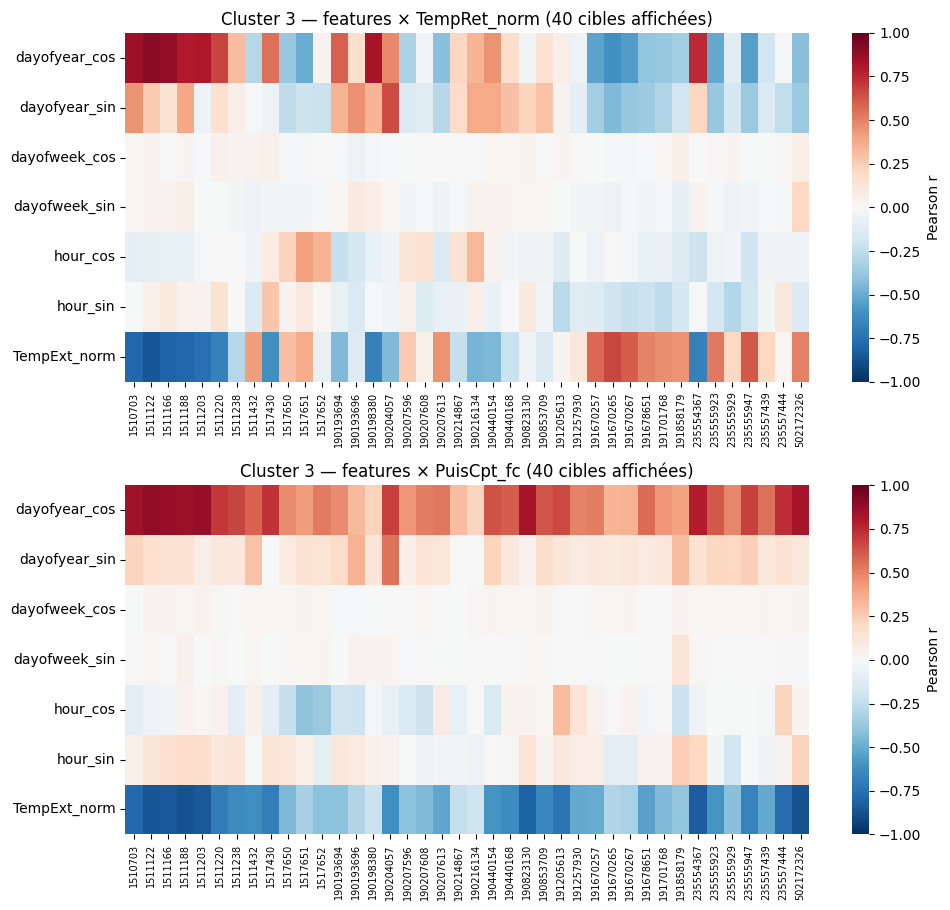

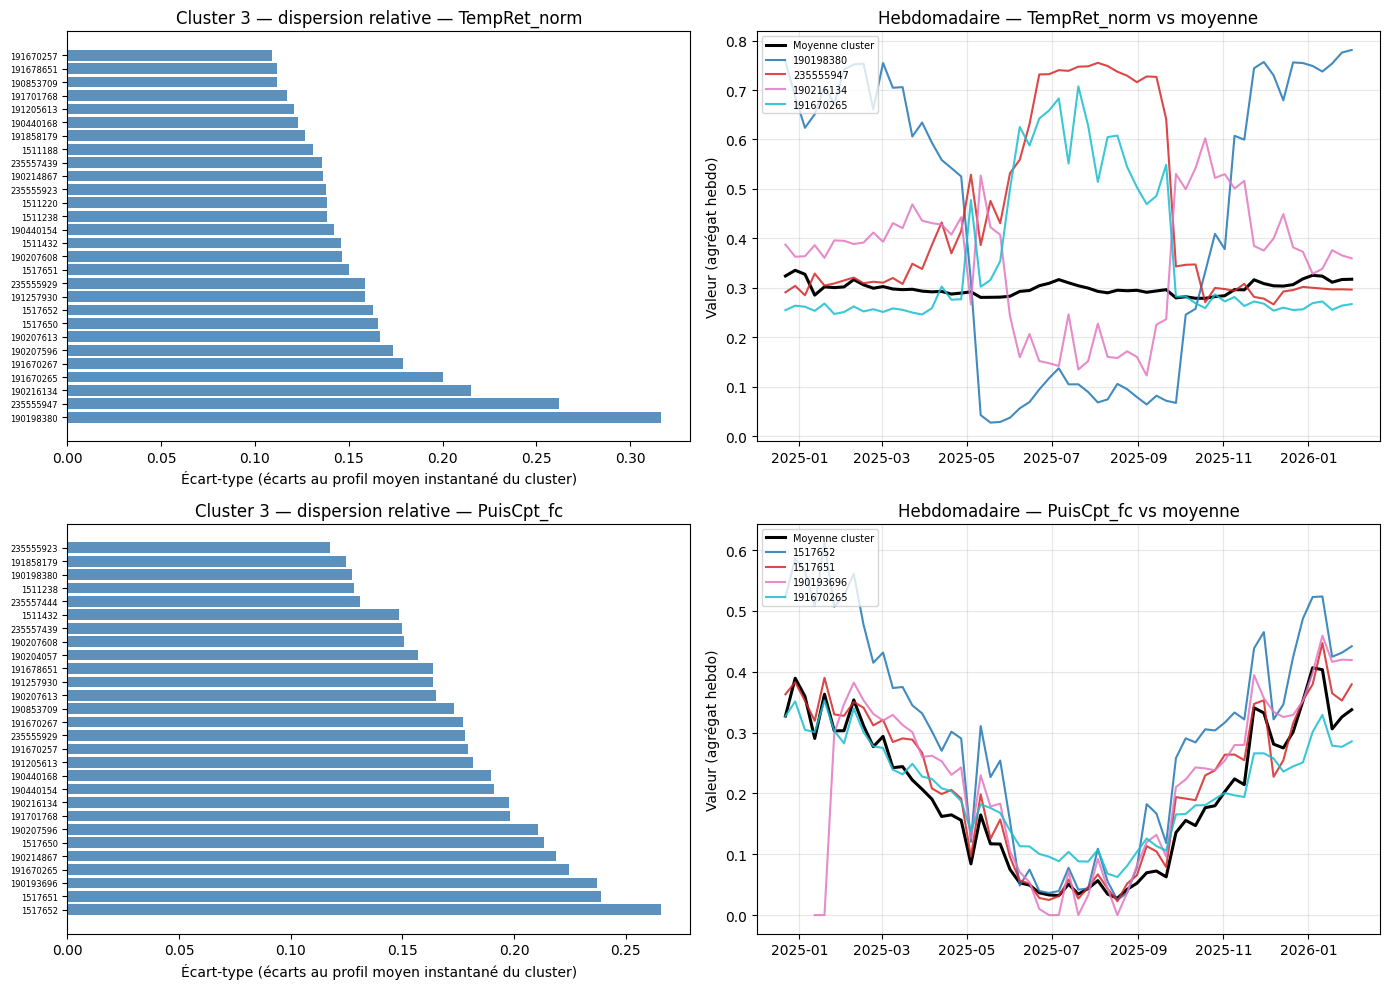

In [5]:
cluster_deep_analysis(3)


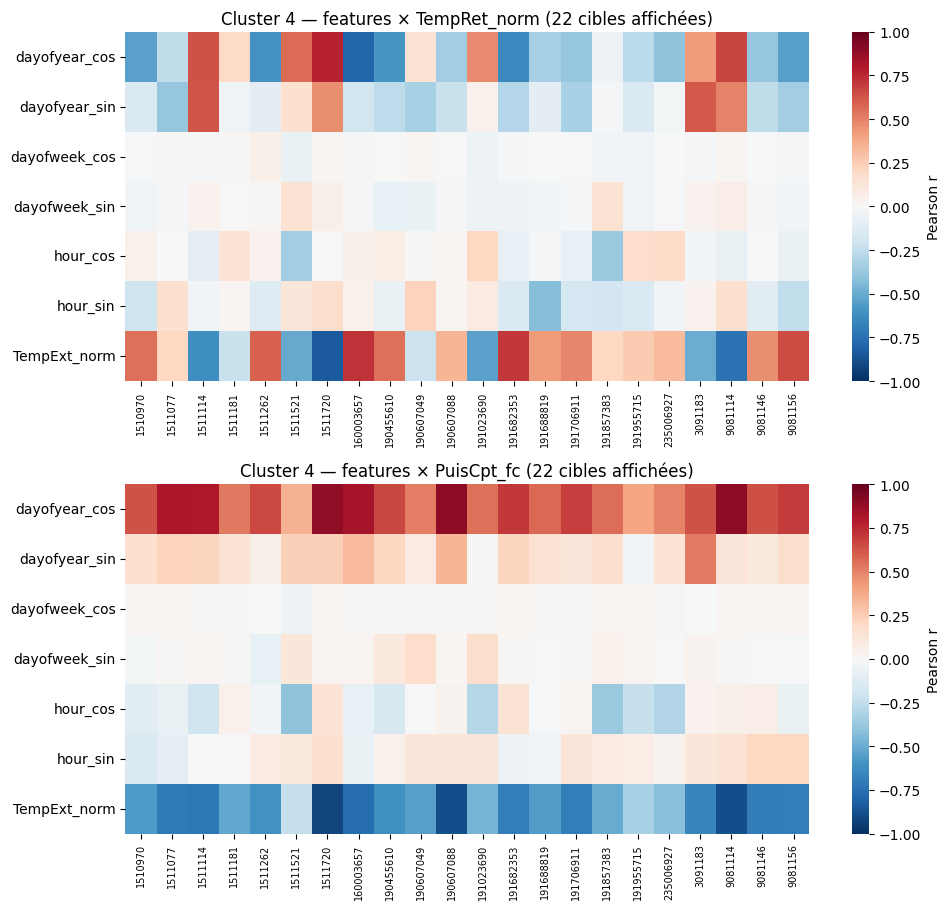

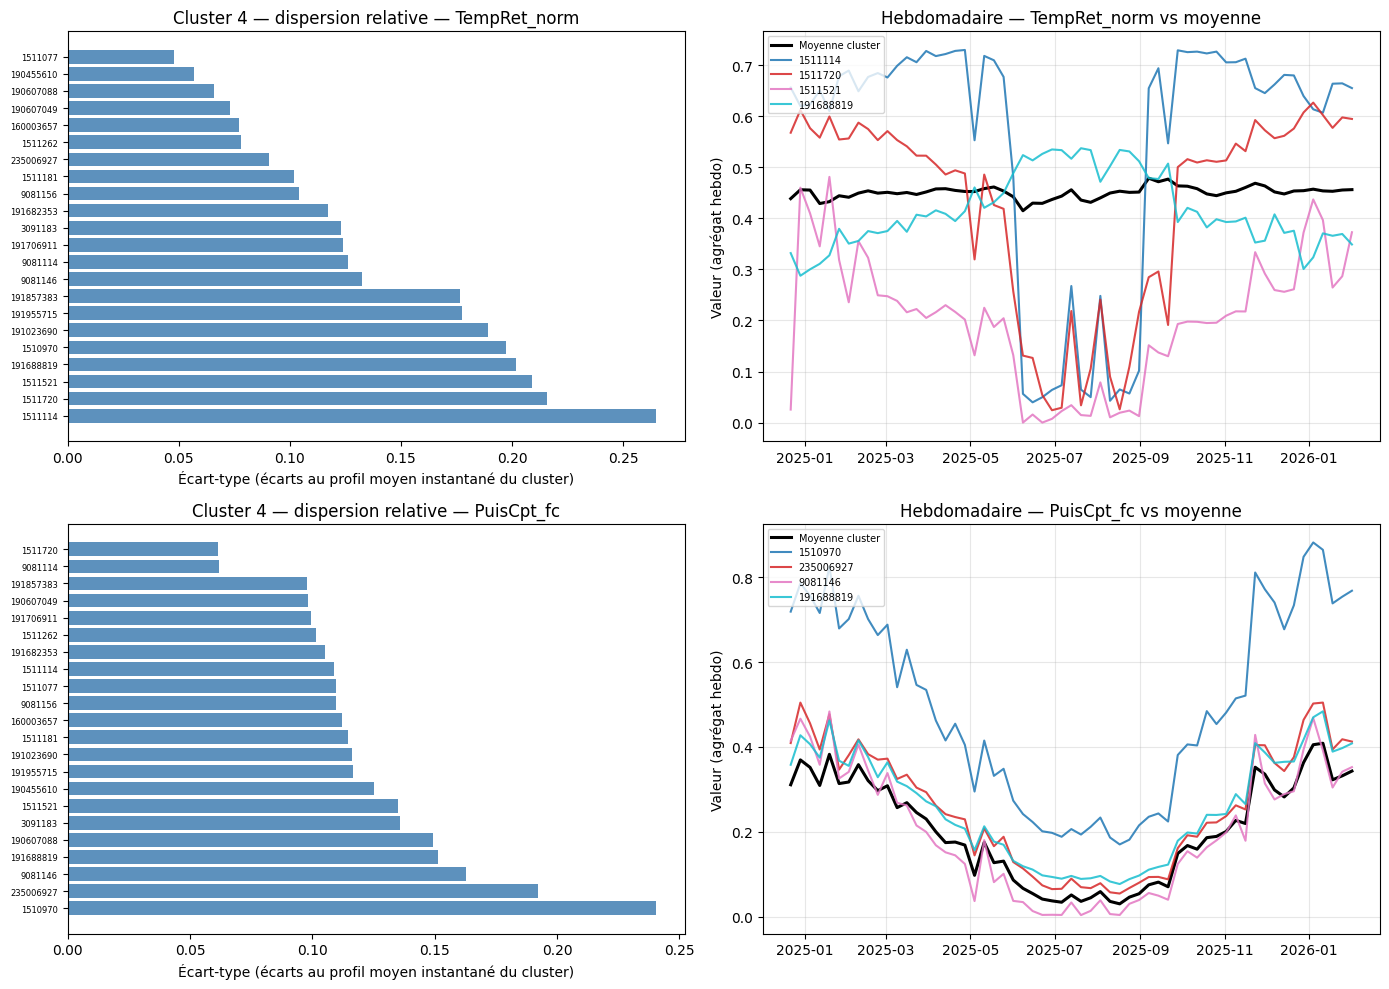

In [6]:
cluster_deep_analysis(4)


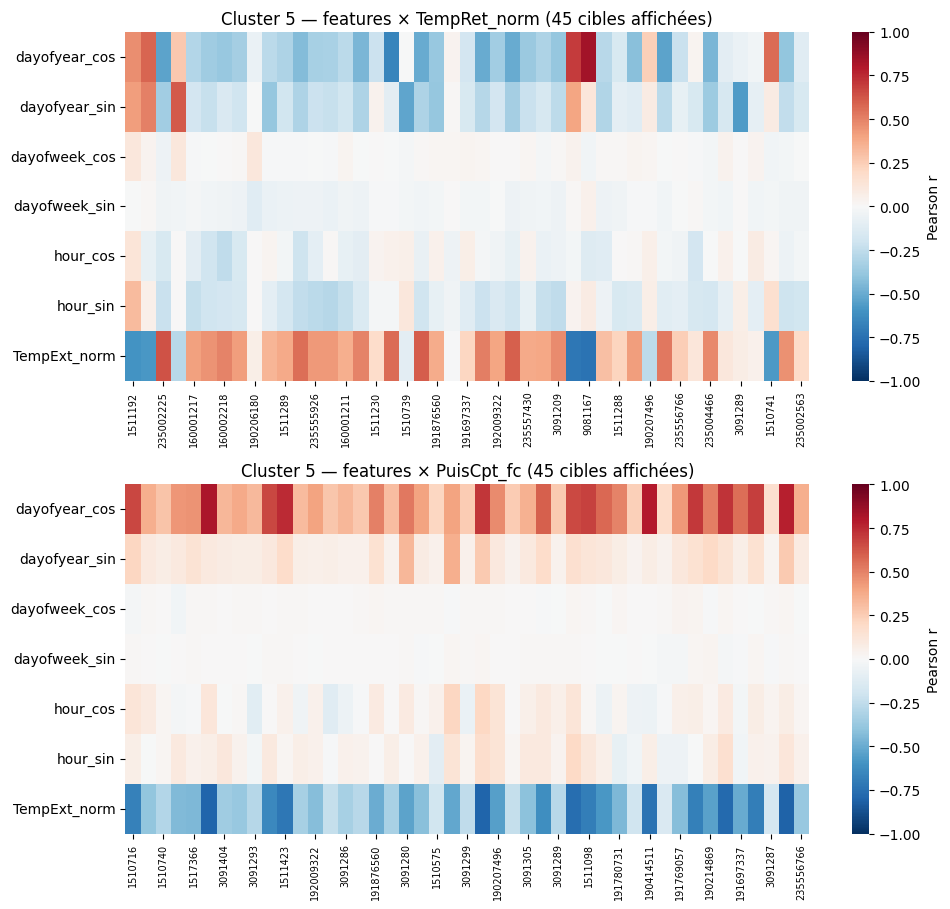

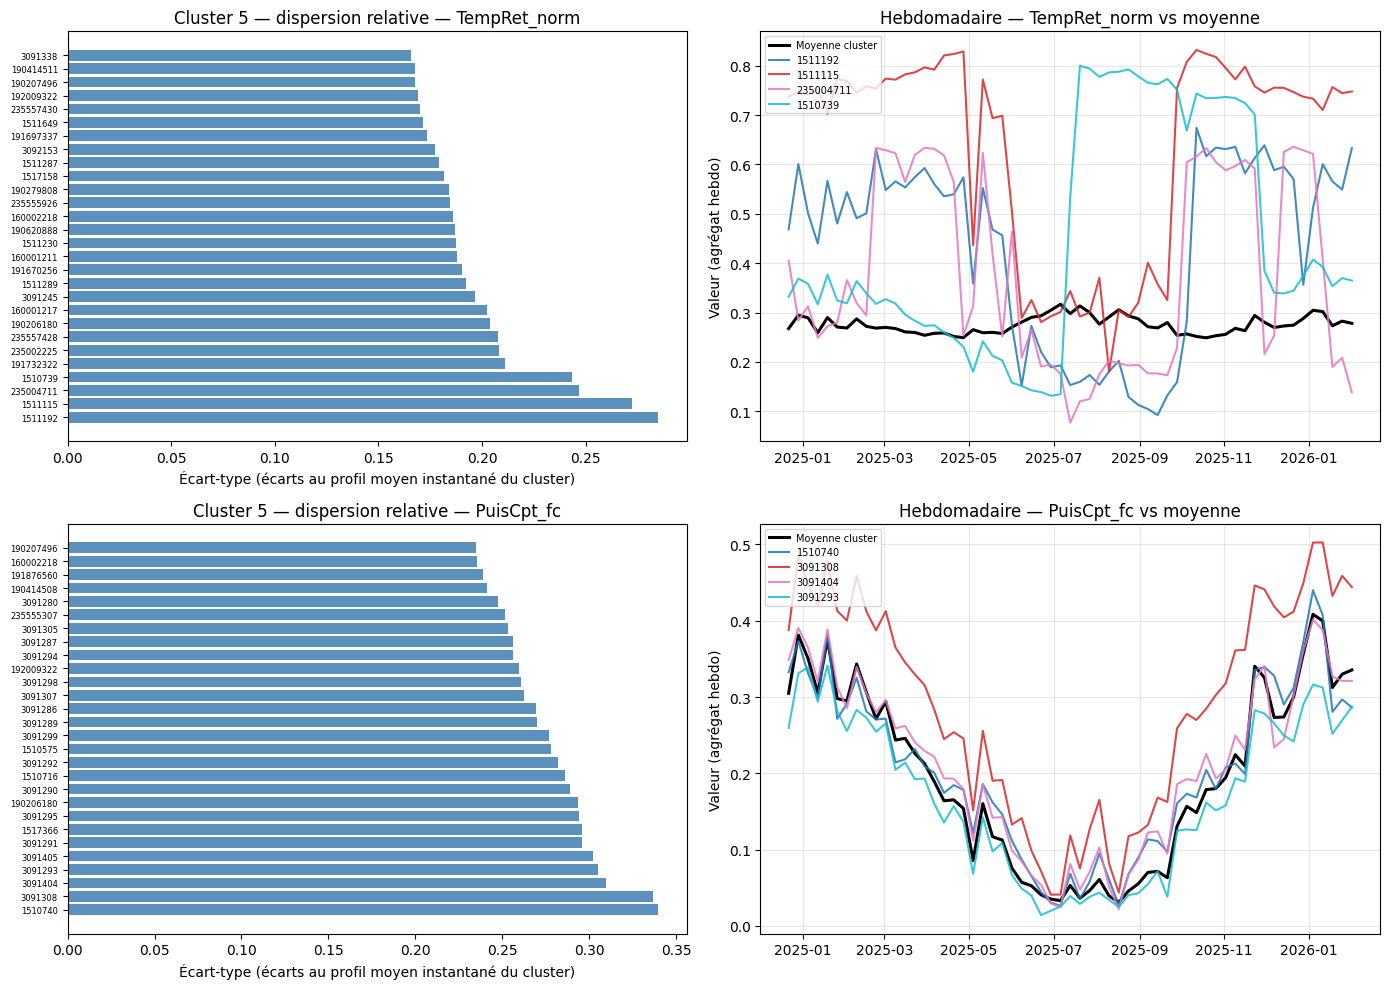

In [7]:
cluster_deep_analysis(5)


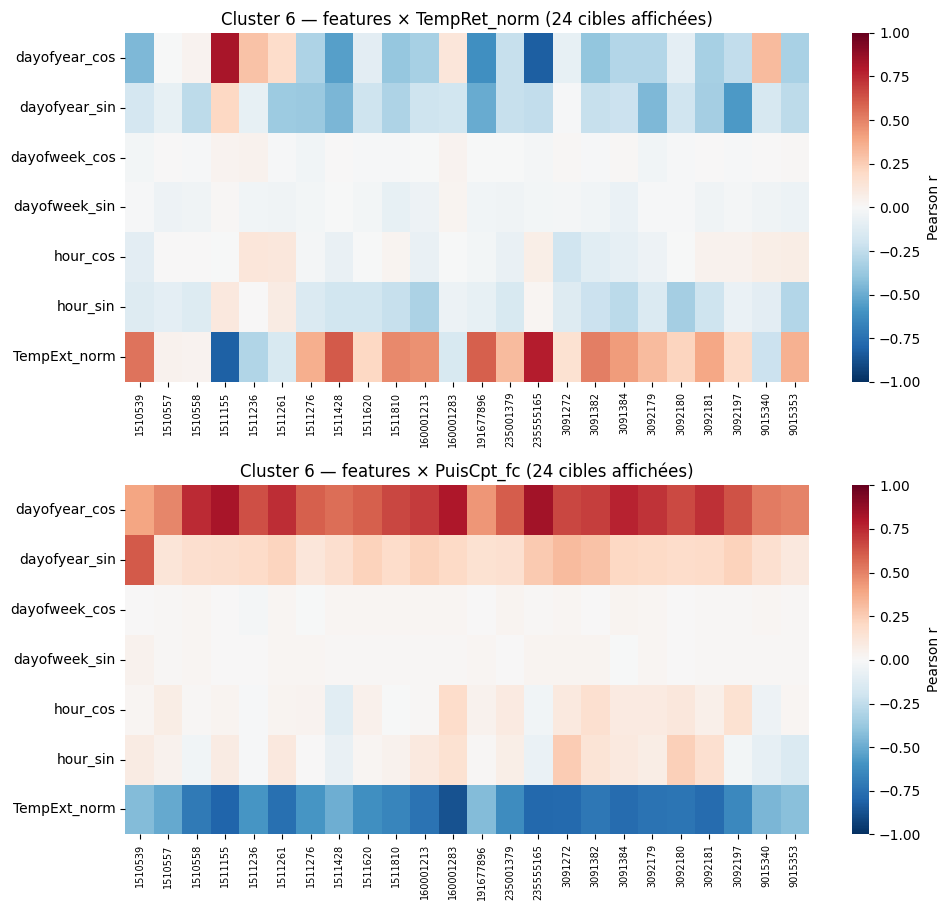

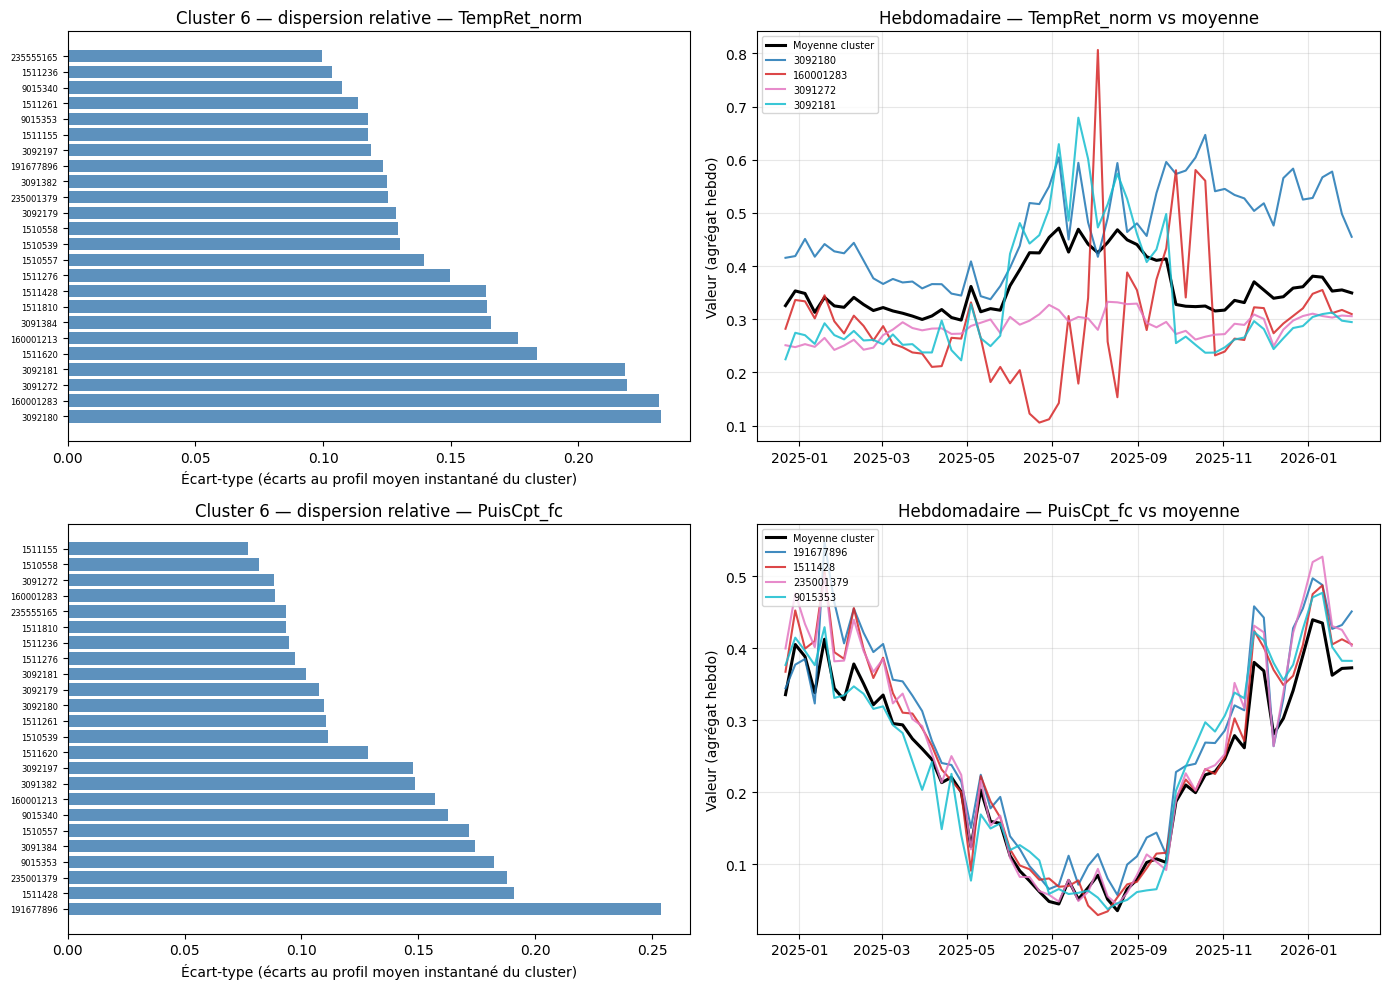

In [8]:
cluster_deep_analysis(6)
